## load

In [1]:
import goatpy as gp
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import squidpy as sq
from napari_spatialdata import Interactive

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warning

In [2]:
sdata_5 = gp.load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML",
                          he_path="/Users/andrewcauser/Documents/Griffith/res_check_0000.tif",tol=0.5)

[0.72GB] Loading peaks ...
[0.72GB]   108 peaks
[0.72GB]   WARNING: H&E pixel size unknown, assuming 0.2527 um/px.


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


[0.72GB]   MALDI pixel size from imzML metadata: 400.0 um/px
[0.72GB]   WARNING: imzML pixel size 400.0 um makes H&E thumbnail (15x12 px) smaller than MALDI (2760x1126 px) -- likely wrong.
[0.72GB]   Falling back to maldi_pixel_um=10.0 um/px.
[0.72GB]   maldi_pixel_um=10.0  he_pixel_um=0.2527
[0.72GB] Computing MALDI crop offsets ...
[0.51GB]   Crop: row=877, col=2638
[0.80GB] Loading 108 ion images (chunk=10) with 0.5 Da tolerance per peak ...


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration 

[0.26GB]   Peaks 1-10 / 108
[0.26GB]   Peaks 11-20 / 108
[0.26GB]   Peaks 21-30 / 108
[0.29GB]   Peaks 31-40 / 108
[0.16GB]   Peaks 41-50 / 108
[0.18GB]   Peaks 51-60 / 108
[0.18GB]   Peaks 61-70 / 108
[0.18GB]   Peaks 71-80 / 108
[0.16GB]   Peaks 81-90 / 108
[0.18GB]   Peaks 91-100 / 108
[0.20GB]   Peaks 101-108 / 108
[0.21GB]   spectra_all: (249, 122, 108)  (13 MB)
[0.21GB] Preparing MALDI template ...
[0.21GB]   MALDI grayscale: (249, 122)  mean=0.217
[0.47GB] Loading H&E at 10.0 um/px ...
[0.68GB]   PIL: 23633x19160
[0.31GB]   Resized to 597x484  10.000 um/px  (1 MB)
[0.31GB]   H&E: 597x484  (1 MB)
[0.31GB] Preparing H&E search image ...
[0.32GB]   H&E grayscale: (484, 597)  mean=0.104
[0.32GB] Running registration ...
[0.32GB]   Coarse: 24 rotations (0-360 step 15) ...
[0.34GB]       0.0  score=0.7724
[0.36GB]      15.0  score=0.5852
[0.38GB]      30.0  score=0.5979
[0.40GB]      45.0  score=0.5609
[0.42GB]      60.0  score=0.5258
[0.43GB]      75.0  score=0.5745
[0.44GB]      90.

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


[1.19GB]   Transform stored: rotation=1.0  he_reg_size=[484, 597]  canvas_placement=[75, 75]
[1.19GB] Done.


In [7]:
from pyimzml.ImzMLParser import ImzMLParser, getionimage
import os
p =  ImzMLParser("/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML",)
def rd_peaks_from_package():

    # Try to get the file from the package
    peaks_path = '/Users/andrewcauser/goatpy/goatpy/data/PEAKS.csv'
    
    if not os.path.exists(peaks_path):
        raise FileNotFoundError(f"PEAKS.csv not found at {peaks_path}")
    
    with open(peaks_path, 'r') as f:
        data = []
        f.readline()  # skip header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': 
                continue
            data.append(float(ss[1]))
    return data

peaks = rd_peaks_from_package()

In [ ]:
peaks[1]

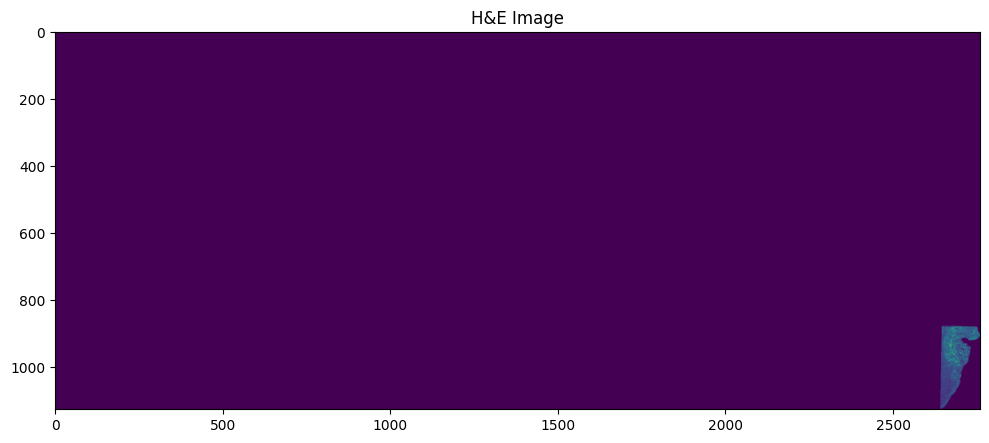

In [17]:
import matplotlib.pyplot as plt
import numpy as np


fig = getionimage(p, 1095.4, tol=0.1, reduce_func=max)
# Plot the image
plt.figure(figsize=(10, 5))
plt.imshow(fig)
plt.title("H&E Image")
plt.tight_layout()
plt.show()

In [18]:
fig.max()

np.float64(1.038)

In [59]:
mz = sdata["maldi_adata"].var_names[6]


/var/folders/f1/3f7gj1393nb0phh8vzn910nm0000gn/T/ipykernel_2680/3897105234.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sdata.tables["maldi_adata"], img_key="hires",


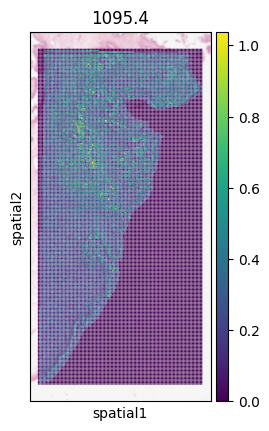

In [60]:
sc.pl.spatial(sdata.tables["maldi_adata"], img_key="hires", 
              color=[mz], size=2, spot_size=5)


/var/folders/f1/3f7gj1393nb0phh8vzn910nm0000gn/T/ipykernel_19693/2459809802.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(sdata_5.tables["maldi_adata"], img_key="hires",


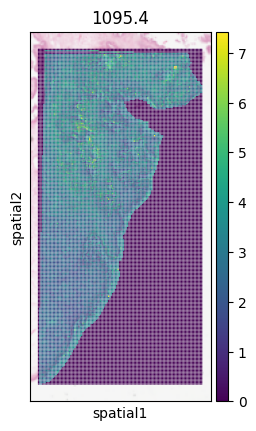

In [4]:
sc.pl.spatial(sdata_5.tables["maldi_adata"], img_key="hires", 
              color=['1095.4'], size=2, spot_size=5)


## bin

In [66]:

"""
binning.py
==========
Data-driven m/z binning for MALDI imzML files.

Instead of loading a pre-defined peak list, this module reads every spectrum
in the imzML file, discovers all m/z values that appear across the dataset,
and bins them into a uniform grid.  This is analogous to Cardinal's approach
and recovers every detectable signal rather than only the ~120 peaks in
PEAKS.csv.

Key concepts
------------
- **bin width (tolerance)**: all m/z values within `tolerance` Da of a bin
  centre are summed into that bin.  A common starting point is 0.05–0.1 Da
  for unit-resolution MALDI instruments; use 0.005–0.02 for high-resolution.
- **bin centres**: derived from the observed m/z range across all spectra so
  no prior knowledge is required.
- **reduce function**: defaults to ``max`` (intensity of the tallest peak
  within the bin window), matching pyimzml's ``getionimage`` convention.
  ``sum`` is also supported and can improve SNR on dense spectra.

Usage
-----
>>> import goatpy as gp
>>> sdata = gp.bin_and_load(
...     imzml_path = "sample.imzML",
...     he_path    = "sample.svs",    # optional H&E
...     tolerance  = 0.05,
...     mz_range   = (900, 3600),     # optional subset
... )

Or just build the binned matrix without H&E registration:

>>> from goatpy.binning import bin_imzml
>>> sdata = bin_imzml("sample.imzML", tolerance=0.05)
"""

from __future__ import annotations

import gc
import os
from functools import partial
from typing import Callable, Literal, Optional, Tuple

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
from shapely.geometry import box as shapely_box

from pyimzml.ImzMLParser import ImzMLParser

from spatialdata import SpatialData
from spatialdata.models import (
    Image2DModel, PointsModel, ShapesModel, TableModel,
)
from spatialdata.transformations import Identity


# ---------------------------------------------------------------------------
# Logging helper (reuses auto_align pattern)
# ---------------------------------------------------------------------------

def _log(msg: str) -> None:
    try:
        import psutil
        rss = psutil.Process(os.getpid()).memory_info().rss / 1e9
        print(f"[{rss:.2f}GB] {msg}")
    except ImportError:
        print(msg)


# ---------------------------------------------------------------------------
# Step 1 — discover global m/z axis
# ---------------------------------------------------------------------------

def _discover_mz_axis(
    parser: ImzMLParser,
    mz_range: Optional[Tuple[float, float]],
    tolerance: float,
    sample_fraction: float = 1.0,
) -> np.ndarray:
    """
    Scan every spectrum (or a random fraction of them) to find the full m/z
    range actually present in the file, then build a uniform bin grid.

    Parameters
    ----------
    parser : ImzMLParser
        Already-opened parser object.
    mz_range : (lo, hi) or None
        Restrict bins to this m/z window.  ``None`` uses the full range.
    tolerance : float
        Bin half-width in Da.  Bin centres are spaced ``2 * tolerance`` apart.
    sample_fraction : float
        Fraction of spectra to scan for range discovery (0–1].  Use < 1 for
        very large files where scanning every spectrum is slow.

    Returns
    -------
    bin_centres : np.ndarray, shape (n_bins,)
        Uniformly spaced bin centre m/z values.
    """
    n_spectra = len(parser.coordinates)
    step = max(1, int(1 / sample_fraction))

    global_lo = np.inf
    global_hi = -np.inf

    _log(f"  Scanning {n_spectra} spectra for m/z range "
         f"(sample_fraction={sample_fraction:.2f}) ...")

    for idx in range(0, n_spectra, step):
        mzs, _ = parser.getspectrum(idx)
        if len(mzs) == 0:
            continue
        lo, hi = float(mzs[0]), float(mzs[-1])
        if lo < global_lo:
            global_lo = lo
        if hi > global_hi:
            global_hi = hi

    if np.isinf(global_lo):
        raise ValueError("No m/z data found in file — all spectra are empty.")

    _log(f"  Observed m/z range: [{global_lo:.4f}, {global_hi:.4f}]")

    # Optionally restrict
    if mz_range is not None:
        global_lo = max(global_lo, mz_range[0])
        global_hi = min(global_hi, mz_range[1])
        _log(f"  Restricted to mz_range=[{global_lo:.4f}, {global_hi:.4f}]")

    # Build uniform grid; bin width = 2 * tolerance
    bin_width = 2.0 * tolerance
    bin_centres = np.arange(global_lo, global_hi + bin_width, bin_width)
    _log(f"  {len(bin_centres):,} bins  (width={bin_width:.4f} Da)")
    return bin_centres


# ---------------------------------------------------------------------------
# Step 2 — bin a single spectrum
# ---------------------------------------------------------------------------

def _bin_spectrum(
    mzs: np.ndarray,
    intensities: np.ndarray,
    bin_centres: np.ndarray,
    tolerance: float,
    reduce: Literal["max", "sum"] = "max",
) -> np.ndarray:
    """
    Map one spectrum onto the global bin grid.

    For each bin centre, collect all intensity values whose m/z falls within
    [centre - tolerance, centre + tolerance] and reduce them to a scalar.

    This is a vectorised implementation using np.searchsorted — it is O(n log n)
    rather than O(n_bins * n_peaks).

    Parameters
    ----------
    mzs : np.ndarray
        Sorted m/z values for this spectrum.
    intensities : np.ndarray
        Corresponding intensity values.
    bin_centres : np.ndarray
        Global bin centre array (sorted, uniformly spaced).
    tolerance : float
        Half-width of each bin in Da.
    reduce : "max" | "sum"
        How to combine multiple peaks within a bin.

    Returns
    -------
    binned : np.ndarray, shape (n_bins,), dtype float32
    """
    mzs = np.asarray(mzs, dtype=np.float64)
    intensities = np.asarray(intensities, dtype=np.float64)

    n_bins = len(bin_centres)
    binned = np.zeros(n_bins, dtype=np.float32)

    if len(mzs) == 0:
        return binned

    # For each bin, find peaks within [centre-tol, centre+tol] using searchsorted
    lo_mz = bin_centres - tolerance
    hi_mz = bin_centres + tolerance

    lo_idx = np.searchsorted(mzs, lo_mz, side="left")
    hi_idx = np.searchsorted(mzs, hi_mz, side="right")

    if reduce == "max":
        for i in range(n_bins):
            a, b = lo_idx[i], hi_idx[i]
            if b > a:
                binned[i] = np.max(intensities[a:b])
    elif reduce == "sum":
        for i in range(n_bins):
            a, b = lo_idx[i], hi_idx[i]
            if b > a:
                binned[i] = np.sum(intensities[a:b])
    else:
        raise ValueError(f"reduce must be 'max' or 'sum', got '{reduce}'")

    return binned


# ---------------------------------------------------------------------------
# Step 3 — load all spectra into a dense matrix
# ---------------------------------------------------------------------------

def _load_binned_matrix(
    imzml_path: str,
    bin_centres: np.ndarray,
    tolerance: float,
    reduce: Literal["max", "sum"] = "max",
    chunk_size: int = 500,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load every spectrum from the imzML and bin it onto the global m/z grid.

    Parameters
    ----------
    imzml_path : str
    bin_centres : np.ndarray
    tolerance : float
    reduce : "max" | "sum"
    chunk_size : int
        Log progress every this many spectra.

    Returns
    -------
    X : np.ndarray, shape (n_pixels, n_bins), float32
        Binned intensity matrix.
    coords : np.ndarray, shape (n_pixels, 2), int
        (x, y) MALDI pixel coordinates (1-based from imzML).
    bin_centres : np.ndarray, shape (n_bins,)
        The bin centres used (passed through for convenience).
    """
    parser = ImzMLParser(imzml_path)
    n_spectra = len(parser.coordinates)
    n_bins = len(bin_centres)

    X = np.zeros((n_spectra, n_bins), dtype=np.float32)
    coords = np.zeros((n_spectra, 2), dtype=np.int32)

    _log(f"  Binning {n_spectra:,} spectra × {n_bins:,} bins ...")

    for idx, (x, y, _) in enumerate(parser.coordinates):
        mzs, intensities = parser.getspectrum(idx)
        X[idx] = _bin_spectrum(mzs, intensities, bin_centres, tolerance, reduce)
        coords[idx] = [x, y]

        if (idx + 1) % chunk_size == 0 or idx == n_spectra - 1:
            _log(f"    {idx + 1:,} / {n_spectra:,}  "
                 f"({(idx + 1) / n_spectra * 100:.1f}%)")

    _log(f"  Matrix shape: {X.shape}  ({X.nbytes / 1e6:.0f} MB)")
    return X, coords, bin_centres


# ---------------------------------------------------------------------------
# Step 4 — optional peak filtering
# ---------------------------------------------------------------------------

def _filter_peaks(
    X: np.ndarray,
    bin_centres: np.ndarray,
    min_frequency: float = 0.0,
    min_intensity: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Drop bins that are too sparse or too weak across the dataset.

    Parameters
    ----------
    X : np.ndarray, shape (n_pixels, n_bins)
    bin_centres : np.ndarray, shape (n_bins,)
    min_frequency : float
        Drop bins detected in fewer than this fraction of pixels (0–1).
        E.g. 0.01 drops bins present in < 1 % of pixels.
    min_intensity : float
        Drop bins whose maximum intensity across all pixels is below this value.

    Returns
    -------
    X_filtered : np.ndarray
    bin_centres_filtered : np.ndarray
    """
    mask = np.ones(X.shape[1], dtype=bool)

    if min_frequency > 0.0:
        freq = (X > 0).mean(axis=0)
        mask &= freq >= min_frequency
        _log(f"  After min_frequency={min_frequency}: "
             f"{mask.sum():,} / {len(mask):,} bins retained")

    if min_intensity > 0.0:
        peak_max = X.max(axis=0)
        mask &= peak_max >= min_intensity
        _log(f"  After min_intensity={min_intensity}: "
             f"{mask.sum():,} / {len(mask):,} bins retained")

    return X[:, mask], bin_centres[mask]


# ---------------------------------------------------------------------------
# Step 5 — assemble SpatialData (no H&E)
# ---------------------------------------------------------------------------

def _build_spatialdata_no_he(
    X: np.ndarray,
    bin_centres: np.ndarray,
    coords: np.ndarray,
    pixel_size: float = 1.0,
) -> SpatialData:
    """
    Build a minimal SpatialData object from binned spectra without H&E.

    Each MALDI pixel becomes a square polygon of side ``pixel_size``.

    Parameters
    ----------
    X : np.ndarray, shape (n_pixels, n_bins)
    bin_centres : np.ndarray, shape (n_bins,)
    coords : np.ndarray, shape (n_pixels, 2)  — (x, y) 1-based
    pixel_size : float
        Edge length of each pixel square in arbitrary units.

    Returns
    -------
    SpatialData
    """
    n_pixels = X.shape[0]

    # Shift to 0-based
    x = coords[:, 0].astype(float) - 1
    y = coords[:, 1].astype(float) - 1

    adata = ad.AnnData(X, dtype=np.float32)
    adata.var_names = [f"{mz:.4f}" for mz in bin_centres]
    adata.obs_names = [str(i) for i in range(n_pixels)]

    adata.obs["x"] = x
    adata.obs["y"] = y
    adata.obs["MPI"] = np.ravel(X.sum(axis=1))
    adata.obsm["spatial"] = np.column_stack([x, y])

    pixel_idx = adata.obs_names.to_numpy()
    half = pixel_size / 2.0
    geoms = [
        shapely_box(float(xi) - half, float(yi) - half,
                    float(xi) + half, float(yi) + half)
        for xi, yi in zip(x, y)
    ]
    gdf = gpd.GeoDataFrame({"cell_id": pixel_idx}, geometry=geoms)
    shapes = ShapesModel.parse(gdf, transformations={"global": Identity()})

    pts_df = pd.DataFrame({"x": x, "y": y, "cell_id": pixel_idx})
    centroids = PointsModel.parse(pts_df)

    sdata = SpatialData(
        points={"centroids": centroids},
        shapes={"pixels": shapes},
    )

    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"] = pd.Categorical(["pixels"] * n_pixels)

    table = TableModel.parse(
        adata, region="pixels",
        region_key="region", instance_key="instance_id",
    )
    sdata["maldi_adata"] = table
    return sdata


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def bin_imzml(
    imzml_path: str,
    tolerance: float = 0.05,
    mz_range: Optional[Tuple[float, float]] = None,
    reduce: Literal["max", "sum"] = "max",
    min_frequency: float = 0.0,
    min_intensity: float = 0.0,
    sample_fraction: float = 1.0,
    chunk_size: int = 500,
) -> SpatialData:
    """
    Load a MALDI imzML file and bin all spectra onto a uniform m/z grid.

    This replaces the manual peak-list workflow (``glyco_spatialdata`` / the
    bundled PEAKS.csv) with a data-driven approach that retains every
    detectable signal.  The result is a SpatialData object compatible with all
    other goatpy functions.

    Parameters
    ----------
    imzml_path : str
        Path to the .imzML file.
    tolerance : float, default 0.05
        Half-width of each m/z bin in Da.  All peaks within
        ``[centre - tolerance, centre + tolerance]`` are collapsed to one bin.

        Recommended values:
        - Low-resolution (unit-res) MALDI:  0.1 – 0.5 Da
        - Medium-resolution:                0.02 – 0.1 Da
        - High-resolution (Orbitrap/FT):    0.002 – 0.01 Da
    mz_range : (lo, hi) or None
        Restrict the output to this m/z window, e.g. ``(900.0, 3600.0)``.
        ``None`` uses the full range found in the file.
    reduce : "max" | "sum", default "max"
        How to combine multiple peaks within one bin.

        - ``"max"``  — tallest peak wins  (matches pyimzml ``getionimage``)
        - ``"sum"``  — integrate all peaks (better SNR for dense spectra)
    min_frequency : float, default 0.0
        After binning, drop m/z bins detected in fewer than this fraction of
        pixels (0.0 = keep all).  E.g. ``0.01`` drops bins present in < 1 % of
        pixels.
    min_intensity : float, default 0.0
        Drop m/z bins whose maximum intensity across all pixels is below this
        value.
    sample_fraction : float, default 1.0
        Fraction of spectra to scan when discovering the m/z range.  Values
        < 1 speed up the range-discovery step on large files but may miss
        rare m/z values.
    chunk_size : int, default 500
        Progress is logged every ``chunk_size`` spectra.

    Returns
    -------
    SpatialData with:
        shapes["pixels"]        — one square per MALDI pixel
        points["centroids"]     — centroid of each pixel
        tables["maldi_adata"]   — AnnData, rows = pixels, columns = m/z bins

    Examples
    --------
    >>> from goatpy.binning import bin_imzml
    >>> sdata = bin_imzml("sample.imzML", tolerance=0.05, mz_range=(900, 3600))
    >>> sdata["maldi_adata"].shape
    (4200, 13500)   # depends on your data

    # Then normalise, reduce, cluster as usual:
    >>> import goatpy as gp
    >>> sdata = gp.normalize_spatialdata(sdata, table_name="maldi_adata")
    >>> sdata = gp.graphpca_spatialdata(sdata, n_components=30)
    >>> sdata = gp.get_kmean_clusters(sdata, n_clusters=8)

    # Or pass directly to load_and_align for H&E registration — just supply
    # the pre-binned sdata instead of using the imzml_path loading path.
    # (H&E registration still runs on the TIC image built from the binned matrix.)
    """
    _log(f"bin_imzml: {imzml_path}")
    _log(f"  tolerance={tolerance} Da  reduce={reduce}  mz_range={mz_range}")

    # ------------------------------------------------------------------
    # 1. Open file and discover m/z axis
    # ------------------------------------------------------------------
    _log("Step 1/4 — discovering m/z axis ...")
    parser = ImzMLParser(imzml_path)
    bin_centres = _discover_mz_axis(
        parser, mz_range, tolerance, sample_fraction
    )
    del parser
    gc.collect()

    # ------------------------------------------------------------------
    # 2. Load and bin all spectra
    # ------------------------------------------------------------------
    _log("Step 2/4 — loading and binning spectra ...")
    X, coords, bin_centres = _load_binned_matrix(
        imzml_path, bin_centres, tolerance, reduce, chunk_size
    )

    # ------------------------------------------------------------------
    # 3. Optional peak filtering
    # ------------------------------------------------------------------
    if min_frequency > 0.0 or min_intensity > 0.0:
        _log("Step 3/4 — filtering low-quality bins ...")
        X, bin_centres = _filter_peaks(X, bin_centres, min_frequency, min_intensity)
    else:
        _log("Step 3/4 — skipping filtering (min_frequency=0, min_intensity=0)")

    # ------------------------------------------------------------------
    # 4. Assemble SpatialData
    # ------------------------------------------------------------------
    _log("Step 4/4 — assembling SpatialData ...")
    sdata = _build_spatialdata_no_he(X, bin_centres, coords)

    _log(
        f"Done.  {sdata['maldi_adata'].shape[0]:,} pixels × "
        f"{sdata['maldi_adata'].shape[1]:,} m/z bins"
    )
    return sdata


def bin_and_align(
    imzml_path: str,
    he_path: str,
    tolerance: float = 0.05,
    mz_range: Optional[Tuple[float, float]] = None,
    reduce: Literal["max", "sum"] = "max",
    min_frequency: float = 0.0,
    min_intensity: float = 0.0,
    geojson_path: Optional[str] = None,
    maldi_pixel_um: Optional[float] = None,
    he_pixel_um: Optional[float] = None,
    img_upscaling: int = 10,
    buffer_px: int = 150,
    coarse_rotation_step: int = 15,
    fine_rotation_range: float = 5.0,
    fine_rotation_step: float = 1.0,
    **kwargs,
) -> SpatialData:
    """
    Bin all spectra from an imzML file and register against an H&E image.

    This is the data-driven equivalent of ``load_and_align``:  instead of
    loading a fixed peak list it bins the entire spectral space first, then
    passes the binned TIC image to the registration engine.

    Parameters
    ----------
    imzml_path, he_path : str
        Paths to imzML and H&E files.
    tolerance : float
        Bin half-width in Da — see ``bin_imzml`` for guidance.
    mz_range : (lo, hi) or None
        Restrict to this m/z window before registration.
    reduce : "max" | "sum"
        Bin reduction function.
    min_frequency, min_intensity : float
        Post-binning quality filters — see ``bin_imzml``.
    geojson_path : str or None
        Optional QuPath annotation export.
    maldi_pixel_um, he_pixel_um : float or None
        Physical pixel sizes.  Auto-detected when None.
    img_upscaling : int
        Upscaling factor for the output canvas.
    buffer_px : int
        Canvas padding at registration resolution.
    coarse_rotation_step, fine_rotation_range, fine_rotation_step : float
        Registration search parameters.

    Returns
    -------
    SpatialData
        Same structure as ``load_and_align`` output.
    """
   
    from PIL import Image as _Image
    from pyimzml.ImzMLParser import ImzMLParser as _Parser
    from spatialdata.models import ShapesModel as _Shapes
    from spatialdata.transformations import Identity as _Id

    # ------------------------------------------------------------------
    # 1. Bin spectra
    # ------------------------------------------------------------------
    _log("=== bin_and_align: Step 1 — binning spectra ===")
    sdata_binned = bin_imzml(
        imzml_path,
        tolerance=tolerance,
        mz_range=mz_range,
        reduce=reduce,
        min_frequency=min_frequency,
        min_intensity=min_intensity,
    )
    adata = sdata_binned["maldi_adata"]
    X = np.asarray(adata.X, dtype=np.float32)
    n_pixels, n_bins = X.shape

    # Reconstruct maldi_h x maldi_w grid from obs x/y
    xs = adata.obs["x"].astype(int).to_numpy()
    ys = adata.obs["y"].astype(int).to_numpy()
    maldi_w = int(xs.max()) + 1
    maldi_h = int(ys.max()) + 1

    spectra_all = np.zeros((maldi_h, maldi_w, n_bins), dtype=np.float32)
    spectra_all[ys, xs, :] = X

    # ------------------------------------------------------------------
    # 2. MALDI pixel size
    # ------------------------------------------------------------------
    if maldi_pixel_um is None:
        detected = _read_maldi_pixel_size(imzml_path)
        maldi_pixel_um = detected if detected is not None else 10.0
        _log(f"  maldi_pixel_um={maldi_pixel_um}")

    # ------------------------------------------------------------------
    # 3. H&E pixel size
    # ------------------------------------------------------------------
    if he_pixel_um is None:
        he_pixel_um = _read_native_mpp(he_path)
        if he_pixel_um is None:
            he_pixel_um = 0.2527
            _log(f"  WARNING: H&E pixel size unknown, assuming {he_pixel_um} um/px.")
        else:
            _log(f"  H&E native pixel size: {he_pixel_um:.4f} um/px")

    # ------------------------------------------------------------------
    # 4. Registration (same pipeline as load_and_align)
    # ------------------------------------------------------------------
    _log("=== bin_and_align: Step 2 — H&E registration ===")
    tic = spectra_all.sum(axis=-1).astype(np.float32)
    maldi_gray = _maldi_to_grayscale(tic)

    he_img, loaded_mpp = _load_he_at_resolution(he_path, maldi_pixel_um, he_pixel_um)
    he_reg_w, he_reg_h = he_img.width, he_img.height
    he_gray = _he_to_grayscale(he_img)

    best_rot, best_idx = _register(
        he_gray, maldi_gray,
        src_w=he_reg_w, src_h=he_reg_h,
        coarse_step=coarse_rotation_step,
        fine_range=fine_rotation_range,
        fine_step=fine_rotation_step,
        buffer_px=buffer_px,
    )
    del he_gray, maldi_gray
    gc.collect()

    he_canvas, M_stored, canvas_pr, canvas_pc = _build_affine_and_canvas(
        he_img=he_img, src_w=he_reg_w, src_h=he_reg_h,
        rotation_deg=best_rot, buffer_px=buffer_px,
    )
    del he_img
    gc.collect()

    # ------------------------------------------------------------------
    # 5. Annotations
    # ------------------------------------------------------------------
    annotation_gdf = None
    if geojson_path is not None:
        annotation_gdf = _transform_geojson(
            geojson_path=geojson_path,
            he_pixel_um=he_pixel_um,
            reg_mpp=loaded_mpp,
            M_stored=M_stored,
            img_upscaling=img_upscaling,
        )

    # ------------------------------------------------------------------
    # 6. Build SpatialData with registered canvas
    # ------------------------------------------------------------------
    _log("=== bin_and_align: Step 3 — building SpatialData ===")
    sdata = _build_spatialdata(
        spectra_all=spectra_all,
        peaks=[float(v) for v in adata.var_names],
        maldi_pixel_um=maldi_pixel_um,
        he_canvas=he_canvas,
        maldi_offset_in_canvas=best_idx,
        reg_mpp=loaded_mpp,
        crop_r=0,
        crop_c=0,
        img_upscaling=img_upscaling,
    )

    if annotation_gdf is not None:
        ann_shapes = _Shapes.parse(annotation_gdf, transformations={"global": _Id()})
        sdata.shapes["annotations"] = ann_shapes

    sdata["maldi_adata"].uns["he_transform"] = {
        "rotation_deg":     float(best_rot),
        "maldi_offset":     [int(best_idx[0]), int(best_idx[1])],
        "he_pixel_um":      float(he_pixel_um),
        "maldi_pixel_um":   float(maldi_pixel_um),
        "reg_mpp":          float(loaded_mpp),
        "buffer_px":        int(buffer_px),
        "img_upscaling":    int(img_upscaling),
        "canvas_shape":     list(he_canvas.shape[:2]),
        "affine_matrix":    M_stored.tolist(),
        "binning": {
            "tolerance":      tolerance,
            "reduce":         reduce,
            "mz_range":       list(mz_range) if mz_range else None,
            "min_frequency":  min_frequency,
            "min_intensity":  min_intensity,
            "n_bins":         int(n_bins),
        },
    }

    _log(
        f"bin_and_align done.  "
        f"{sdata['maldi_adata'].shape[0]:,} pixels × "
        f"{sdata['maldi_adata'].shape[1]:,} m/z bins"
    )
    return sdata

In [ ]:
sdata_b = bin_imzml(
    imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML",
    tolerance=0.05,          # bin half-width in Da
    mz_range=(900, 3600),    # optional window
    reduce="max",            # or "sum"
    min_frequency=0.01,      # drop bins seen in <1% of pixels
)

In [ ]:
"""
plot_spectrum.py
================
Spectral visualisation utilities for goatpy.

Provides ``plot_spectrum``, which plots the mean binned spectrum from a
SpatialData object and optionally overlays the original curated peak list
from a CSV file (the same format as PEAKS.csv / glycan_list.csv).

Usage
-----
>>> from goatpy.plot_spectrum import plot_spectrum

# Basic — just the mean binned spectrum
>>> plot_spectrum(sdata)

# With the original curated peak CSV overlaid
>>> plot_spectrum(sdata, peaks_csv="goatpy/data/PEAKS.csv")

# With glycan annotations
>>> plot_spectrum(sdata, peaks_csv="goatpy/data/glycan_list.csv",
...              label_col="Composition", mz_col="Theoretical m/z [M+Na]")

# Restrict m/z window
>>> plot_spectrum(sdata, mz_range=(1200, 2000))

# Plot a single pixel instead of the mean
>>> plot_spectrum(sdata, pixel_index=42)
"""

from __future__ import annotations

from pathlib import Path
from typing import Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from spatialdata import SpatialData


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def _read_peaks_csv(
    csv_path: Union[str, Path],
    mz_col: Optional[str] = None,
    label_col: Optional[str] = None,
) -> pd.DataFrame:
    """
    Read a peak CSV and return a DataFrame with columns ``mz`` and ``label``.

    Handles both goatpy CSV formats:
      - PEAKS.csv          : space-separated, column 2 is m/z, no labels
      - glycan_list.csv    : comma-separated, columns = [m/z, Composition]

    Parameters
    ----------
    csv_path   : path to CSV file
    mz_col     : explicit column name for m/z.  Auto-detected when None.
    label_col  : explicit column name for labels.  Optional.

    Returns
    -------
    DataFrame with columns:
        ``mz``    : float
        ``label`` : str (empty string when no label column found)
    """
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(f"Peaks CSV not found: {path}")

    # Try to detect separator
    with open(path, "r") as f:
        header = f.readline()
    sep = "," if "," in header else r"\s+"

    df = pd.read_csv(path, sep=sep, engine="python")
    df.columns = [str(c).strip().strip('"') for c in df.columns]

    # ---- auto-detect m/z column ----
    if mz_col is None:
        candidates = [
            c for c in df.columns
            if any(k in c.lower() for k in ["mz", "m/z", "mass", "theoretical"])
        ]
        if candidates:
            mz_col = candidates[0]
        else:
            # Fall back to first numeric column
            numeric_cols = df.select_dtypes(include=[float, int]).columns.tolist()
            if not numeric_cols:
                # Try coercing
                for c in df.columns:
                    try:
                        pd.to_numeric(df[c], errors="raise")
                        numeric_cols = [c]
                        break
                    except Exception:
                        continue
            if not numeric_cols:
                raise ValueError(
                    f"Could not find an m/z column in {path}. "
                    f"Columns: {list(df.columns)}. "
                    f"Pass mz_col= explicitly."
                )
            mz_col = numeric_cols[0]

    mz = pd.to_numeric(df[mz_col], errors="coerce").dropna()
    idx = mz.index

    # ---- auto-detect label column ----
    if label_col is None:
        label_candidates = [
            c for c in df.columns
            if c != mz_col and any(
                k in c.lower()
                for k in ["composition", "name", "label", "glycan", "annotation"]
            )
        ]
        label_col = label_candidates[0] if label_candidates else None

    if label_col is not None and label_col in df.columns:
        labels = df[label_col].iloc[idx].fillna("").astype(str).tolist()
    else:
        labels = [""] * len(mz)

    return pd.DataFrame({"mz": mz.values, "label": labels})


def _get_spectrum(
    sdata: SpatialData,
    table_name: str,
    pixel_index: Optional[int],
    reduce: str,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract a 1-D spectrum (m/z, intensity) from a SpatialData table.

    Parameters
    ----------
    sdata        : SpatialData object (output of bin_imzml or load_and_align)
    table_name   : key in sdata.tables
    pixel_index  : row index to plot; None → reduce across all pixels
    reduce       : "mean" | "median" | "max" | "sum"  (used when pixel_index is None)

    Returns
    -------
    (mz_values, intensities) : np.ndarray, np.ndarray
    """
    if table_name not in sdata.tables:
        raise KeyError(
            f"Table '{table_name}' not found. "
            f"Available: {list(sdata.tables.keys())}"
        )

    adata = sdata.tables[table_name]

    try:
        mz_values = np.array(adata.var_names, dtype=float)
    except ValueError:
        raise ValueError(
            f"var_names could not be converted to float.  "
            f"Ensure the table was created by bin_imzml (var_names = m/z strings)."
        )

    X = np.asarray(adata.X, dtype=np.float32)

    if pixel_index is not None:
        if pixel_index < 0 or pixel_index >= X.shape[0]:
            raise IndexError(
                f"pixel_index={pixel_index} out of range "
                f"[0, {X.shape[0] - 1}]."
            )
        intensities = X[pixel_index]
    else:
        fn = {"mean": np.mean, "median": np.median,
              "max": np.max, "sum": np.sum}.get(reduce)
        if fn is None:
            raise ValueError(f"reduce must be mean/median/max/sum, got '{reduce}'")
        intensities = fn(X, axis=0)

    return mz_values, intensities.astype(np.float64)


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def plot_spectrum(
    sdata: SpatialData,
    peaks_csv: Optional[Union[str, Path]] = None,
    mz_col: Optional[str] = None,
    label_col: Optional[str] = None,
    table_name: str = "maldi_adata",
    pixel_index: Optional[int] = None,
    reduce: str = "mean",
    mz_range: Optional[Tuple[float, float]] = None,
    tolerance: float = 0.1,
    label_top_n: int = 20,
    label_min_intensity_pct: float = 5.0,
    figsize: Tuple[float, float] = (14, 5),
    spectrum_color: str = "#3a6fa8",
    peak_color: str = "#d9534f",
    peak_linewidth: float = 1.2,
    spectrum_linewidth: float = 0.8,
    ax: Optional[plt.Axes] = None,
    title: Optional[str] = None,
    show: bool = True,
    save_path: Optional[Union[str, Path]] = None,
) -> plt.Axes:
    """
    Plot the binned spectrum from a SpatialData object, with optional overlay
    of a curated peak list CSV.

    Parameters
    ----------
    sdata : SpatialData
        Output of ``bin_imzml``, ``bin_and_align``, or ``load_and_align``.
    peaks_csv : str or Path, optional
        Path to a CSV file with curated peak m/z values (PEAKS.csv format or
        glycan_list.csv format).  When supplied, each curated peak is marked
        on the spectrum with a vertical dashed line.
    mz_col : str, optional
        Column name for m/z values in ``peaks_csv``.  Auto-detected when None.
    label_col : str, optional
        Column name for peak labels in ``peaks_csv`` (e.g. "Composition").
        Labels are drawn above the highest-intensity annotated peaks.
    table_name : str, default "maldi_adata"
        Table to read from ``sdata.tables``.
    pixel_index : int, optional
        Plot a single pixel's spectrum.  Plots the mean across all pixels
        when None.
    reduce : "mean" | "median" | "max" | "sum", default "mean"
        Reduction applied across all pixels when ``pixel_index`` is None.
    mz_range : (lo, hi), optional
        Restrict the x-axis to this m/z window.
    tolerance : float, default 0.1
        m/z tolerance (Da) used to match curated peaks to binned bin centres.
        A curated peak at 1257.5 Da will be matched if a bin centre lies
        within ±``tolerance`` Da.
    label_top_n : int, default 20
        Maximum number of peak labels drawn (to avoid overlap).  The
        highest-intensity matched peaks are labelled first.
    label_min_intensity_pct : float, default 5.0
        Only draw a label if the matched bin's intensity is ≥ this percentage
        of the maximum spectrum intensity.
    figsize : (width, height), default (14, 5)
    spectrum_color : str, default "#3a6fa8"
        Line colour for the binned spectrum.
    peak_color : str, default "#d9534f"
        Colour for curated peak overlay lines and labels.
    peak_linewidth : float, default 1.2
    spectrum_linewidth : float, default 0.8
    ax : matplotlib Axes, optional
        Plot into an existing Axes.  A new figure is created when None.
    title : str, optional
        Axes title.  Auto-generated when None.
    show : bool, default True
        Call ``plt.show()`` at the end.
    save_path : str or Path, optional
        If supplied, save the figure to this path before showing.

    Returns
    -------
    ax : matplotlib Axes

    Examples
    --------
    >>> plot_spectrum(sdata)
    >>> plot_spectrum(sdata, peaks_csv="goatpy/data/PEAKS.csv",
    ...              mz_range=(900, 2000))
    >>> plot_spectrum(sdata, peaks_csv="goatpy/data/glycan_list.csv",
    ...              mz_col="Theoretical m/z [M+Na]",
    ...              label_col="Composition",
    ...              label_top_n=30)
    >>> ax = plot_spectrum(sdata, show=False)   # embed in larger figure
    """

    # ------------------------------------------------------------------
    # 1. Extract spectrum
    # ------------------------------------------------------------------
    mz_values, intensities = _get_spectrum(sdata, table_name, pixel_index, reduce)

    # ------------------------------------------------------------------
    # 2. Optional m/z window filter
    # ------------------------------------------------------------------
    if mz_range is not None:
        lo, hi = mz_range
        mask = (mz_values >= lo) & (mz_values <= hi)
        mz_values = mz_values[mask]
        intensities = intensities[mask]
        if len(mz_values) == 0:
            raise ValueError(f"No bins found in mz_range={mz_range}.")

    # ------------------------------------------------------------------
    # 3. Load curated peaks CSV
    # ------------------------------------------------------------------
    peaks_df = None
    if peaks_csv is not None:
        peaks_df = _read_peaks_csv(peaks_csv, mz_col=mz_col, label_col=label_col)
        if mz_range is not None:
            peaks_df = peaks_df[
                (peaks_df["mz"] >= mz_range[0]) & (peaks_df["mz"] <= mz_range[1])
            ].copy()

    # ------------------------------------------------------------------
    # 4. Build figure
    # ------------------------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    # Spectrum
    ax.plot(mz_values, intensities,
            color=spectrum_color,
            linewidth=spectrum_linewidth,
            alpha=0.85,
            zorder=2,
            label="Binned spectrum")

    # Light shading under curve
    ax.fill_between(mz_values, intensities,
                    color=spectrum_color, alpha=0.07, zorder=1)

    # ------------------------------------------------------------------
    # 5. Curated peak overlay
    # ------------------------------------------------------------------
    if peaks_df is not None and len(peaks_df) > 0:
        max_intensity = float(intensities.max()) if intensities.max() > 0 else 1.0
        min_label_int = label_min_intensity_pct / 100.0 * max_intensity

        matched_peaks = []  # (mz_curated, mz_bin, intensity, label)

        for _, row in peaks_df.iterrows():
            curated_mz = float(row["mz"])
            label = str(row["label"])

            # Find nearest bin within tolerance
            diffs = np.abs(mz_values - curated_mz)
            best_idx = int(np.argmin(diffs))
            if diffs[best_idx] <= tolerance:
                matched_peaks.append((
                    curated_mz,
                    float(mz_values[best_idx]),
                    float(intensities[best_idx]),
                    label,
                ))

        # Draw vertical dashed lines for all matched peaks
        _drawn_vlines = 0
        for curated_mz, bin_mz, intensity, label in matched_peaks:
            ax.axvline(
                x=curated_mz,
                color=peak_color,
                linewidth=peak_linewidth,
                linestyle="--",
                alpha=0.6,
                zorder=3,
            )
            _drawn_vlines += 1

        # Draw labels for top-N by intensity
        label_candidates = sorted(
            [(intensity, curated_mz, bin_mz, label)
             for curated_mz, bin_mz, intensity, label in matched_peaks
             if intensity >= min_label_int and label],
            reverse=True,
        )

        # Simple collision avoidance: track last labelled x positions
        labelled_x: list[float] = []
        min_x_gap = (mz_values[-1] - mz_values[0]) * 0.015

        drawn_labels = 0
        for intensity, curated_mz, bin_mz, label in label_candidates:
            if drawn_labels >= label_top_n:
                break

            # Skip if too close to an already-labelled peak
            if any(abs(curated_mz - lx) < min_x_gap for lx in labelled_x):
                continue

            y_pos = intensity + max_intensity * 0.03
            ax.annotate(
                label,
                xy=(curated_mz, intensity),
                xytext=(curated_mz, y_pos),
                fontsize=7.5,
                color=peak_color,
                ha="center",
                va="bottom",
                rotation=90,
                annotation_clip=True,
                arrowprops=None,
                zorder=5,
            )
            labelled_x.append(curated_mz)
            drawn_labels += 1

        print(
            f"  Curated peaks: {len(peaks_df)} in CSV  |  "
            f"{len(matched_peaks)} matched within ±{tolerance} Da  |  "
            f"{drawn_labels} labelled"
        )

    # ------------------------------------------------------------------
    # 6. Formatting
    # ------------------------------------------------------------------
    ax.set_xlabel("m/z (Da)", fontsize=12)
    ax.set_ylabel(
        f"{'Pixel ' + str(pixel_index) if pixel_index is not None else reduce.capitalize()} intensity",
        fontsize=12,
    )

    if title is None:
        n_pixels = sdata.tables[table_name].shape[0]
        n_bins   = sdata.tables[table_name].shape[1]
        if pixel_index is not None:
            title = f"Pixel {pixel_index} spectrum — {n_bins:,} bins"
        else:
            title = (
                f"{reduce.capitalize()} spectrum  —  "
                f"{n_pixels:,} pixels × {n_bins:,} bins"
            )
    ax.set_title(title, fontsize=13, pad=10)

    # Legend
    legend_handles = [
        Line2D([0], [0], color=spectrum_color, linewidth=1.5,
               label="Binned spectrum"),
    ]
    if peaks_df is not None and len(peaks_df) > 0:
        legend_handles.append(
            Line2D([0], [0], color=peak_color, linewidth=peak_linewidth,
                   linestyle="--", label=f"Curated peaks (n={len(matched_peaks)})")
        )
    ax.legend(handles=legend_handles, fontsize=10, framealpha=0.6,
              loc="upper right")

    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(5))
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.set_xlim(mz_values[0], mz_values[-1])
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved to {save_path}")

    if show:
        plt.show()

    return ax


# ---------------------------------------------------------------------------
# Convenience: plot multiple pixels as overlaid spectra
# ---------------------------------------------------------------------------

def plot_spectra_comparison(
    sdata: SpatialData,
    pixel_indices: list[int],
    peaks_csv: Optional[Union[str, Path]] = None,
    mz_col: Optional[str] = None,
    label_col: Optional[str] = None,
    table_name: str = "maldi_adata",
    mz_range: Optional[Tuple[float, float]] = None,
    tolerance: float = 0.1,
    label_top_n: int = 15,
    figsize: Tuple[float, float] = (14, 5),
    show: bool = True,
    save_path: Optional[Union[str, Path]] = None,
) -> plt.Axes:
    """
    Overlay spectra from multiple pixels on a single axes.

    Parameters
    ----------
    sdata : SpatialData
    pixel_indices : list of int
        Row indices to overlay.
    peaks_csv, mz_col, label_col, table_name, mz_range,
    tolerance, label_top_n, figsize, show, save_path : same as ``plot_spectrum``

    Returns
    -------
    ax : matplotlib Axes
    """
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=figsize)

    mz_values_all = None
    for i, px in enumerate(pixel_indices):
        mz_values, intensities = _get_spectrum(sdata, table_name, px, "mean")

        if mz_range is not None:
            lo, hi = mz_range
            mask = (mz_values >= lo) & (mz_values <= hi)
            mz_values = mz_values[mask]
            intensities = intensities[mask]

        ax.plot(mz_values, intensities,
                linewidth=0.9, alpha=0.8,
                color=cmap(i % 10),
                label=f"Pixel {px}",
                zorder=2 + i)
        if mz_values_all is None:
            mz_values_all = mz_values

    # Curated peak overlay using mean spectrum for matching
    if peaks_csv is not None and mz_values_all is not None:
        _, mean_int = _get_spectrum(sdata, table_name, None, "mean")
        if mz_range is not None:
            lo, hi = mz_range
            mask = (mz_values_all >= lo) & (mz_values_all <= hi)
            mean_int = mean_int[mask]

        # Reuse plot_spectrum's peak overlay by passing a temp axes
        # (simpler than duplicating logic)
        _tmp_fig, _tmp_ax = plt.subplots()
        plot_spectrum(
            sdata, peaks_csv=peaks_csv,
            mz_col=mz_col, label_col=label_col,
            table_name=table_name,
            mz_range=mz_range,
            tolerance=tolerance,
            label_top_n=label_top_n,
            ax=_tmp_ax,
            show=False,
        )
        # Copy peak vlines and annotations to main axes
        for line in _tmp_ax.lines:
            if line.get_linestyle() == "--":
                ax.axvline(
                    x=line.get_xdata()[0],
                    color="#d9534f", linewidth=1.2,
                    linestyle="--", alpha=0.5, zorder=1,
                )
        for ann in _tmp_ax.texts:
            ax.add_artist(ann)
        plt.close(_tmp_fig)

    ax.set_xlabel("m/z (Da)", fontsize=12)
    ax.set_ylabel("Intensity", fontsize=12)
    ax.set_title(
        f"Spectral comparison — {len(pixel_indices)} pixels",
        fontsize=13, pad=10,
    )
    ax.legend(fontsize=9, framealpha=0.6)
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(5))
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()

    return ax

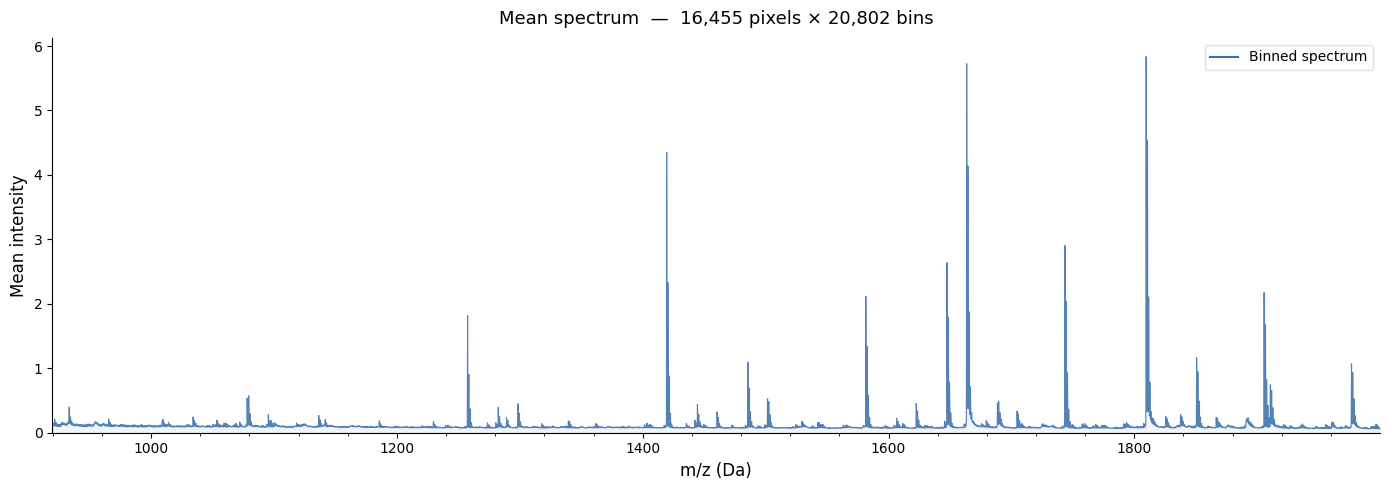

<Axes: title={'center': 'Mean spectrum  —  16,455 pixels × 20,802 bins'}, xlabel='m/z (Da)', ylabel='Mean intensity'>

In [41]:
plot_spectrum(sdata_b, mz_range=(900, 2000))


In [4]:
from pyimzml.ImzMLParser import ImzMLParser, getionimage
?getionimage

Signature: getionimage(p, mz_value, tol=0.1, z=1, reduce_func=<built-in function sum>)
Docstring:
Get an image representation of the intensity distribution
of the ion with specified m/z value.

By default, the intensity values within the tolerance region are summed.

:param p:
    the ImzMLParser (or anything else with similar attributes) for the desired dataset
:param mz_value:
    m/z value for which the ion image shall be returned
:param tol:
    Absolute tolerance for the m/z value, such that all ions with values
    mz_value-|tol| <= x <= mz_value+|tol| are included. Defaults to 0.1
:param z:
    z Value if spectrogram is 3-dimensional.
:param reduce_func:
    the bahaviour for reducing the intensities between mz_value-|tol| and mz_value+|tol| to a single value. Must
    be a function that takes a sequence as input and outputs a number. By default, the values are summed.

:return:
    numpy matrix with each element representing the ion intensity in this
    pixel. Can be easily pl

In [67]:
sdata_a = bin_and_align(
    imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML",
    he_path="/Users/andrewcauser/Documents/Griffith/res_check_0000.tif",
    tolerance=0.05,          # bin half-width in Da
    mz_range=(900, 3600),    # optional window
    reduce="max",            # or "sum"
    min_frequency=0.01,      # drop bins seen in <1% of pixels
)

[0.07GB] === bin_and_align: Step 1 — binning spectra ===
[0.07GB] bin_imzml: /Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML
[0.07GB]   tolerance=0.05 Da  reduce=max  mz_range=(900, 3600)
[0.07GB] Step 1/4 — discovering m/z axis ...


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


[0.08GB]   Scanning 16455 spectra for m/z range (sample_fraction=1.00) ...
[0.08GB]   Observed m/z range: [919.5021, 2999.6125]
[0.08GB]   Restricted to mz_range=[919.5021, 2999.6125]
[0.08GB]   20,803 bins  (width=0.1000 Da)
[0.51GB] Step 2/4 — loading and binning spectra ...
[0.51GB]   Binning 16,455 spectra × 20,803 bins ...
[0.05GB]     500 / 16,455  (3.0%)
[0.10GB]     1,000 / 16,455  (6.1%)
[0.08GB]     1,500 / 16,455  (9.1%)
[0.05GB]     2,000 / 16,455  (12.2%)
[0.12GB]     2,500 / 16,455  (15.2%)
[0.05GB]     3,000 / 16,455  (18.2%)
[0.07GB]     3,500 / 16,455  (21.3%)
[0.09GB]     4,000 / 16,455  (24.3%)
[0.09GB]     4,500 / 16,455  (27.3%)
[0.05GB]     5,000 / 16,455  (30.4%)
[0.06GB]     5,500 / 16,455  (33.4%)
[0.07GB]     6,000 / 16,455  (36.5%)
[0.11GB]     6,500 / 16,455  (39.5%)
[0.06GB]     7,000 / 16,455  (42.5%)
[0.10GB]     7,500 / 16,455  (45.6%)
[0.07GB]     8,000 / 16,455  (48.6%)
[0.10GB]     8,500 / 16,455  (51.7%)
[0.06GB]     9,000 / 16,455  (54.7%)
[0.09GB] 

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


[1.48GB] Done.  16,455 pixels × 20,802 m/z bins


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession MS:1002302 found with incorrect name "Bruker Container file". Updating name to "Bruker Container format".
  warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


[0.66GB]   maldi_pixel_um=400.0
[0.66GB]   WARNING: H&E pixel size unknown, assuming 0.2527 um/px.
[0.66GB] === bin_and_align: Step 2 — H&E registration ===


: 

## align

In [64]:
"""
auto_align.py
=============
Auto-registration of a MALDI imzML dataset against a whole-slide H&E image.

Key design decisions
--------------------
1.  Registration is performed at MALDI native pixel size (default 10 um/px)
    so the H&E thumbnail is tiny and peak RAM stays manageable.

2.  Matching uses normalised grayscale cross-correlation (TM_CCOEFF_NORMED)
    on the TIC image vs inverted H&E intensity.

3.  A two-pass rotation search (coarse 0-360, then fine) finds the correct
    slide orientation without assuming any starting angle.

4.  Registration, canvas building, and annotation transforms all use
    cv2.warpAffine with the same analytically derived affine matrix.
    This guarantees that best_idx, canvas pixels, and annotation coordinates
    all live in the same coordinate system.

Coordinate system
-----------------
All three steps share the same affine matrix M_stored:

    M_stored maps: reg-resolution H&E coords -> canvas coords

    _match_at_rotation  uses cv2.warpAffine(M_stored) to build the search canvas
    _build_affine_and_canvas uses cv2.warpAffine(M_stored) to build output canvas
    _transform_geojson  applies M_up @ M_stored @ M_scale to annotation vertices

Because the same matrix is used everywhere, best_idx from matchTemplate is
directly valid as the MALDI placement offset in the output canvas.
"""

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

import numpy as np
import csv
from pyimzml.ImzMLParser import ImzMLParser, getionimage
from joblib import Parallel, delayed
from functools import partial
import anndata as ad
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from anndata import AnnData
from spatialdata import SpatialData
from spatialdata.models import PointsModel, Image2DModel, TableModel, ShapesModel
from spatialdata.transformations import Identity
import pkg_resources
import os



def parmap(f, X, nprocs=None):
    """
    Parallel map using joblib (more robust for Jupyter).
    
    Parameters
    ----------
    f : callable
        Function to apply to each element
    X : iterable
        Input data
    nprocs : int, optional
        Number of processes (default: -1, all CPUs)
    
    Returns
    -------
    list
        Results in same order as input
    """
    if nprocs is None:
        nprocs = -1  # Use all CPUs
    
    return Parallel(n_jobs=nprocs, backend='loky')(
        delayed(f)(x) for x in X
    )


def getimage(peak, path, tol = 0.1): 
    p =  ImzMLParser(path) #individual file pointers otherwise parsing is corrupted
    return getionimage(p, peak, tol=tol, reduce_func=max)
    

def rd_peaks(fn):

    with open(fn, newline='', encoding='utf-8-sig') as f:
        # Detect delimiter by sniffing the first line
        sample = f.read(4096)
        f.seek(0)
        try:
            dialect = csv.Sniffer().sniff(sample, delimiters=',\t ')
        except csv.Error:
            dialect = csv.excel  # fallback to comma

        reader = csv.reader(f, dialect)
        header = next(reader)

        # 1. Try to find a column whose name contains 'm/z' (case-insensitive)
        mz_col = next(
            (i for i, h in enumerate(header) if 'm/z' in h.lower()),
            None
        )

        if mz_col is not None:
            col_idx = mz_col
        elif len(header) == 1:
            warnings.warn(
                "No 'm/z' column found. Attempting to infer column with numeric values."
            )
            # Single-column file — read col 0 but skip the header we already consumed
            col_idx = 0
        else:
            warnings.warn(
                "No 'm/z' column found. Attempting to infer column with numeric values."
            )
            # Multi-column, no m/z header found — fall back to column index 1
            col_idx = 1

        data = []
        for row in reader:
            if col_idx >= len(row):
                continue
            val = row[col_idx].strip().strip('"')
            try:
                data.append(float(val))
            except ValueError:
                continue  # skip non-numeric rows

    return data


def rd_peaks_from_package():

    # Try to get the file from the package
    peaks_path = pkg_resources.resource_filename('goatpy', 'data/PEAKS.csv')
    
    if not os.path.exists(peaks_path):
        raise FileNotFoundError(f"PEAKS.csv not found at {peaks_path}")
    
    with open(peaks_path, 'r') as f:
        data = []
        f.readline()  # skip header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': 
                continue
            data.append(float(ss[1]))
    return data


def glyco_spatialdata(imzml_path, peaks_path = None, tol = 0.1, pixel_size = 20):

    # Load Peaks
    if peaks_path is None:
        peaks = rd_peaks_from_package()
    else:
        peaks = rd_peaks(peaks_path)

    # Load ImzML data
    getimg = partial(getimage, path=imzml_path, tol = tol)

    spectra_all = np.stack(
        parmap(getimg, peaks, 10),
        axis=-1
    )

    # Load Spatial Info
    p = ImzMLParser(imzml_path)
    coords = np.array(p.coordinates)[:, :2]  # (x, y)
    coords = coords - 1  # convert from 1-based to 0-based indexing
    

    # Create AnnData Object
    spectra_flat = np.array([spectra_all[y-1, x-1, :] for x, y in coords])
    anndata = ad.AnnData(spectra_flat, dtype=np.float32)
    anndata.var_names = np.array(["%.1f" % p for p in peaks])
    anndata.obs_names = np.array(list(map(str, range(len(coords)))))
    anndata.obs["full_x"] = coords[:, 0]
    anndata.obs["full_y"] = coords[:, 1]

    anndata.obs["x"] = anndata.obs["full_x"] - anndata.obs["full_x"].min() 
    anndata.obs["y"] = anndata.obs["full_y"] - anndata.obs["full_y"].min()
    

    anndata.obsm["spatial"] = np.column_stack([anndata.obs["x"], anndata.obs["y"]])


    # Calculate Total Ion Count (TIC)
    anndata.obs["MPI"] = np.ravel(anndata.X.sum(axis=1))

    
    # Create SpatialData Object
    coords = pd.DataFrame({
        "x": [c for c in anndata.obs["x"]],
        "y": [c for c in anndata.obs["y"]],
    })

    coords["instance_id"] = coords.index.astype(str)      # unique ID for each pixel
    coords["region"] = "pixels"                  # must exist for TableModel

    df = pd.concat(
        [
            coords.reset_index(drop=True),
            pd.DataFrame(anndata.X, columns=("mz-" + anndata.var.index))
        ],
        axis=1
    )

    
    points = PointsModel.parse(df)

    gdf = centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0)  
    
    shapes = ShapesModel.parse(
                gdf[["instance_id", "geometry"]],
                transformations={"global": Identity()},
                )


    sdata = SpatialData(points={"centroids": points},
                        shapes={"pixels": shapes})


    adata = AnnData(
        X=anndata.X,
        obs=coords,  # contains x, y, point_id, region
        var=pd.DataFrame(index=("mz-" + anndata.var.index))
    )

    adata.obs = pd.concat(
        [
            adata.obs.reset_index(drop=True),
            anndata.obs.drop(columns=["x", "y"]).iloc[:adata.n_obs].reset_index(drop=True)
        ],
        axis=1
    )

    coords = np.array(adata.obs[["x", "y"]])

    adata.obsm["spatial"] = coords
    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"] = "pixels"
    adata.obs["region"].astype("category")



    table = TableModel.parse(
        adata,
        region="pixels",      # name of your PointsModel
        region_key="region",        # must exist in adata.obs
        instance_key="instance_id"     # unique per row
    )

    # --- 7. Add to SpatialData ---
    sdata.tables["maldi_adata"] = table

    return sdata


def centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0):
    
    half = pixel_size / 2
    
    geometries = [
        box(x - half, y - half, x + half, y + half)
        for x, y in zip(df[x_col], df[y_col])
    ]
    
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=geometries,
    )
    
    return gdf


from pyimzml.ImzMLParser import ImzMLParser


# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------

def _log(msg: str) -> None:
    try:
        import psutil
        rss = psutil.Process(os.getpid()).memory_info().rss / 1e9
        print(f"[{rss:.2f}GB] {msg}")
    except ImportError:
        print(msg)


# ---------------------------------------------------------------------------
# H&E loading
# ---------------------------------------------------------------------------

def _read_native_mpp(he_path: str) -> Optional[float]:
    """Read native microns-per-pixel from file metadata without loading pixels."""
    try:
        import openslide
        slide = openslide.OpenSlide(he_path)
        mpp_x = slide.properties.get(openslide.PROPERTY_NAME_MPP_X)
        mpp_y = slide.properties.get(openslide.PROPERTY_NAME_MPP_Y)
        slide.close()
        if mpp_x and mpp_y:
            return (float(mpp_x) + float(mpp_y)) / 2.0
    except Exception:
        pass
    return None


def _load_he_at_resolution(he_path: str,
                            target_mpp: float,
                            native_mpp: float) -> tuple[Image.Image, float]:
    """
    Load H&E at (or just finer than) target_mpp using openslide pyramid
    selection, then resize to exactly target_mpp.
    """
    ext = os.path.splitext(he_path)[1].lower()
    wsi_exts = {'.svs', '.ndpi', '.scn', '.czi', '.mrxs'}

    try:
        import openslide
        slide = openslide.OpenSlide(he_path)

        best_level = 0
        best_mpp   = native_mpp
        for lvl in range(slide.level_count):
            lvl_mpp = native_mpp * slide.level_downsamples[lvl]
            if lvl_mpp <= target_mpp * 1.05:
                best_level = lvl
                best_mpp   = lvl_mpp

        dims   = slide.level_dimensions[best_level]
        region = slide.read_region((0, 0), best_level, dims)
        img    = region.convert('RGB')
        slide.close()
        _log(f"  openslide level {best_level}: {dims[0]}x{dims[1]}  "
             f"{best_mpp:.3f} um/px  ({img.width*img.height*3/1e6:.0f} MB)")

        if abs(best_mpp - target_mpp) / target_mpp > 0.02:
            scale = best_mpp / target_mpp
            nw    = max(1, round(img.width  * scale))
            nh    = max(1, round(img.height * scale))
            img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
            best_mpp = target_mpp
            _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px")

        return img, best_mpp

    except Exception as e:
        if ext in wsi_exts:
            raise RuntimeError(
                f"\nFailed to open '{he_path}' with openslide: {e}\n\n"
                "SVS/NDPI files require openslide:\n"
                "  conda install -c conda-forge openslide openslide-python\n"
            ) from e

    img = Image.open(he_path).convert('RGB')
    _log(f"  PIL: {img.width}x{img.height}")
    scale = native_mpp / target_mpp
    nw    = max(1, round(img.width  * scale))
    nh    = max(1, round(img.height * scale))
    img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
    _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px  ({nw*nh*3/1e6:.0f} MB)")
    return img, target_mpp


# ---------------------------------------------------------------------------
# MALDI loading
# ---------------------------------------------------------------------------

def _load_spectra(imzml_path: str,
                  peaks: list[float],
                  chunk_size: int = 10,
                  crop_r: int = 0,
                  crop_c: int = 0,
                  tol: float = 0.1) -> np.ndarray:
    from pyimzml.ImzMLParser import getionimage
    p0    = ImzMLParser(imzml_path)
    probe = getionimage(p0, peaks[0], tol=tol, reduce_func=max)
    h     = probe.shape[0] - crop_r
    w     = probe.shape[1] - crop_c
    del probe

    out = np.zeros((h, w, len(peaks)), dtype=np.float32)
    for start in range(0, len(peaks), chunk_size):
        batch = peaks[start: start + chunk_size]
        imgs  = parmap(partial(getimage, path=imzml_path, tol=tol), batch,
                       nprocs=min(len(batch), 4))
        for j, img in enumerate(imgs):
            out[:, :, start + j] = img[crop_r:, crop_c:]
        del imgs
        _log(f"  Peaks {start+1}-{min(start+len(batch), len(peaks))} / {len(peaks)}")
    return out


def _read_maldi_pixel_size(imzml_path: str) -> Optional[float]:
    try:
        p = ImzMLParser(imzml_path)
        for key in ['pixel size (x)', 'pixel size x', 'pixel size']:
            val = p.imzmldict.get(key)
            if val is not None:
                return float(val)
    except Exception:
        pass
    return None


def _crop_offsets(spectra_sum: np.ndarray, cutoff: float = 0.5) -> tuple[int, int]:
    try:
        crop_c = int(max(np.where(np.sum(spectra_sum, axis=0) < cutoff)[0]))
        crop_r = int(max(np.where(np.sum(spectra_sum, axis=1) < cutoff)[0]))
        return crop_r, crop_c
    except (ValueError, IndexError):
        return 0, 0


# ---------------------------------------------------------------------------
# Image preparation
# ---------------------------------------------------------------------------

def _maldi_to_grayscale(tic: np.ndarray) -> np.ndarray:
    blurred = cv.GaussianBlur(tic, (3, 3), 0)
    mn, mx  = blurred.min(), blurred.max()
    norm    = (blurred - mn) / (mx - mn) if mx > mn else blurred * 0.0
    _log(f"  MALDI grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


def _he_to_grayscale(he_img: Image.Image) -> np.ndarray:
    gray = np.array(he_img.convert('L'), dtype=np.float32)
    inv  = 255.0 - gray
    mn, mx = inv.min(), inv.max()
    norm   = (inv - mn) / (mx - mn) if mx > mn else inv * 0.0
    _log(f"  H&E grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


# ---------------------------------------------------------------------------
# Affine matrix construction (shared by registration and canvas building)
# ---------------------------------------------------------------------------

def _build_affine_matrix(
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
    min_w: int = 0,
    min_h: int = 0,
) -> tuple[np.ndarray, int, int, int, int]:
    """
    Compute the affine matrix that:
        1. Rotates CCW around the image centre ((src_w-1)/2, (src_h-1)/2)
        2. Shifts so the rotated bounding box starts at (0, 0)
        3. Centres the result in a buffer canvas, which is guaranteed to be
           at least (min_w, min_h) pixels so matchTemplate never fails.

    This function is called by both _match_at_rotation (registration) and
    _build_affine_and_canvas (output), so both steps share the identical
    coordinate system and best_idx is directly valid in the output canvas.

    Parameters
    ----------
    src_w, src_h  : H&E image dimensions at registration resolution
    rotation_deg  : CCW rotation in degrees
    buffer_px     : symmetric padding added around the rotated image
    min_w, min_h  : minimum canvas dimensions (set to MALDI template size
                    during registration to guarantee matchTemplate succeeds
                    at all rotation angles including 90/270 degree flips)

    Returns
    -------
    M_stored  : np.ndarray (3, 3) -- reg-res H&E coords -> canvas coords
    canvas_w  : int
    canvas_h  : int
    canvas_pc : int -- col offset
    canvas_pr : int -- row offset
    """
    theta = np.deg2rad(rotation_deg)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    cx = (src_w - 1) / 2.0
    cy = (src_h - 1) / 2.0

    corners = np.array([
        [0.0,       0.0      ],
        [src_w - 1, 0.0      ],
        [src_w - 1, src_h - 1],
        [0.0,       src_h - 1],
    ], dtype=np.float64)

    dx = corners[:, 0] - cx
    dy = corners[:, 1] - cy
    rot_x = cos_t * dx - sin_t * dy + cx
    rot_y = sin_t * dx + cos_t * dy + cy

    expand_x = rot_x.min()
    expand_y = rot_y.min()

    rot_w = int(np.ceil(rot_x.max() - rot_x.min()))
    rot_h = int(np.ceil(rot_y.max() - rot_y.min()))

    # Guarantee the canvas is large enough for the MALDI template at all
    # rotation angles. At 90/270 degrees the rotated H&E bounding box swaps
    # width and height, which can make the canvas narrower than the template.
    # We expand symmetrically so the affine translation stays centred.
    canvas_w  = max(rot_w + buffer_px, min_w)
    canvas_h  = max(rot_h + buffer_px, min_h)
    canvas_pc = (canvas_w - rot_w) // 2
    canvas_pr = (canvas_h - rot_h) // 2

    tx = -cos_t * cx + sin_t * cy + cx - expand_x + canvas_pc
    ty = -sin_t * cx - cos_t * cy + cy - expand_y + canvas_pr

    M_stored = np.array([
        [ cos_t, -sin_t, tx],
        [ sin_t,  cos_t, ty],
        [   0.0,    0.0, 1.0],
    ], dtype=np.float64)

    return M_stored, canvas_w, canvas_h, canvas_pc, canvas_pr


# ---------------------------------------------------------------------------
# Registration — now using cv2 so coordinate system matches canvas building
# ---------------------------------------------------------------------------

def _match_at_rotation(
    he_gray: np.ndarray,
    maldi_gray: np.ndarray,
    rotation: float,
    buffer_px: int,
) -> tuple[float, tuple[int, int]]:
    """
    Rotate the H&E grayscale image using the same cv2.warpAffine convention
    as _build_affine_and_canvas, then run matchTemplate.

    Because the rotation is applied identically here and in the output canvas
    builder, best_idx returned here is directly valid as the MALDI placement
    offset in the final canvas — no coordinate remapping needed.

    Parameters
    ----------
    he_gray    : float32 grayscale H&E at reg resolution
    maldi_gray : float32 grayscale MALDI TIC template
    rotation   : CCW rotation in degrees
    buffer_px  : canvas padding — must match _build_affine_and_canvas

    Returns
    -------
    score  : float, normalised cross-correlation score
    loc    : (row, col) top-left of best template match in canvas coords
    """
    src_h, src_w = he_gray.shape
    tmpl_h, tmpl_w = maldi_gray.shape

    # Pass template dimensions as minimum canvas size so the canvas is always
    # large enough for matchTemplate at every rotation angle, including 90/270
    # degree cases where the rotated H&E bounding box swaps width and height.
    M_stored, canvas_w, canvas_h, _, _ = _build_affine_matrix(
        src_w, src_h, rotation, buffer_px,
        min_w=tmpl_w, min_h=tmpl_h,
    )

    M_cv = M_stored[:2, :]
    canvas = cv.warpAffine(
        he_gray,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=0.0,
    )

    result           = cv.matchTemplate(canvas, maldi_gray, cv.TM_CCOEFF_NORMED)
    _, score, _, loc = cv.minMaxLoc(result)
    return float(score), (int(loc[1]), int(loc[0]))   # (row, col)


def _register(
    he_gray: np.ndarray,
    maldi_gray: np.ndarray,
    src_w: int,
    src_h: int,
    coarse_step: int = 15,
    fine_range: float = 5.0,
    fine_step: float = 1.0,
    buffer_px: int = 150,
) -> tuple[float, tuple[int, int]]:
    """
    Two-pass rotation + translation search using cv2-based matching.

    src_w and src_h are passed explicitly (they equal he_gray.shape[1] and
    he_gray.shape[0]) so that _build_affine_matrix can be called with the
    same values used later by _build_affine_and_canvas.
    """
    coarse_rots = list(range(0, 360, coarse_step))
    _log(f"  Coarse: {len(coarse_rots)} rotations (0-360 step {coarse_step}) ...")

    best_score = -np.inf
    best_rot   = 0.0
    best_idx   = (0, 0)

    for rot in coarse_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, buffer_px)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, float(rot), idx

    _log(f"  Best coarse: {best_rot}  score={best_score:.4f}")

    fine_rots = sorted({
        round(best_rot + d, 1)
        for d in np.arange(-fine_range, fine_range + fine_step, fine_step)
        if abs(d) > 1e-6
    })
    _log(f"  Fine: {len(fine_rots)} rotations (+-{fine_range} step {fine_step}) ...")

    for rot in fine_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, buffer_px)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, rot, idx

    _log(f"  Final: {best_rot}  score={best_score:.4f}  offset={best_idx}")
    return best_rot, best_idx


# ---------------------------------------------------------------------------
# Build H&E output canvas
# ---------------------------------------------------------------------------

def _build_affine_and_canvas(
    he_img: Image.Image,
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
) -> tuple[np.ndarray, np.ndarray, int, int]:
    """
    Build the H&E output canvas using cv2.warpAffine.

    Calls _build_affine_matrix with the identical arguments used in
    _match_at_rotation, so the canvas geometry here is byte-for-byte the
    same as the search canvas used during registration.

    Returns
    -------
    canvas    : np.ndarray (H, W, 3) uint8
    M_stored  : np.ndarray (3, 3) float64 -- reg-res coords -> canvas coords
    canvas_pr : int
    canvas_pc : int
    """
    M_stored, canvas_w, canvas_h, canvas_pc, canvas_pr = _build_affine_matrix(
        src_w, src_h, rotation_deg, buffer_px
    )

    img_np = np.array(he_img, dtype=np.uint8)
    M_cv   = M_stored[:2, :]
    canvas = cv.warpAffine(
        img_np,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=(0, 0, 0),
    )

    _log(f"  H&E canvas (cv2): {canvas_w}x{canvas_h}  "
         f"pr={canvas_pr}, pc={canvas_pc}  rotation={rotation_deg}")

    return canvas, M_stored, canvas_pr, canvas_pc


# ---------------------------------------------------------------------------
# Annotation transform
# ---------------------------------------------------------------------------

def _transform_geojson(
    geojson_path: Union[str, Path],
    he_pixel_um: float,
    reg_mpp: float,
    M_stored: np.ndarray,
    img_upscaling: int,
    classification_key: str = "classification",
) -> gpd.GeoDataFrame:
    """
    Transform QuPath GeoJSON annotations (native H&E pixel coords) into the
    final upscaled canvas coordinate system.

    Full pipeline:
        M_annotations = M_up @ M_stored @ M_scale

    where:
        M_scale  : native H&E pixels -> reg-resolution pixels
        M_stored : reg-res coords -> canvas coords  (from _build_affine_matrix)
        M_up     : canvas coords -> upscaled canvas coords
    """
    with open(geojson_path, "r") as f:
        geojson = json.load(f)

    features = geojson if isinstance(geojson, list) else geojson.get("features", [])
    if not features:
        raise ValueError(f"No features found in {geojson_path}")

    scale_to_reg = he_pixel_um / reg_mpp
    us           = float(img_upscaling)

    M_scale = np.array([
        [scale_to_reg, 0.0,          0.0],
        [0.0,          scale_to_reg, 0.0],
        [0.0,          0.0,          1.0],
    ], dtype=np.float64)

    M_up = np.array([
        [us,  0.0, 0.0],
        [0.0, us,  0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    M = M_up @ M_stored @ M_scale

    a, b, tx = M[0, 0], M[0, 1], M[0, 2]
    d, e, ty = M[1, 0], M[1, 1], M[1, 2]

    def _apply(coords: np.ndarray) -> np.ndarray:
        x, y = coords[:, 0], coords[:, 1]
        return np.column_stack([
            a * x + b * y + tx,
            d * x + e * y + ty,
        ])

    geoms, labels, names = [], [], []
    for feat in features:
        geom_raw = feat.get("geometry")
        if geom_raw is None:
            continue
        geoms.append(shapely_transform(shape(geom_raw), _apply))
        props  = feat.get("properties") or {}
        clf    = props.get("classification") or {}
        labels.append(clf.get("name", "unknown") if isinstance(clf, dict) else str(clf))
        names.append(props.get("name", ""))

    return gpd.GeoDataFrame(
        {classification_key: labels, "name": names},
        geometry=geoms,
    )


# ---------------------------------------------------------------------------
# SpatialData construction
# ---------------------------------------------------------------------------

def _build_spatialdata(spectra_all: np.ndarray,
                       peaks: list[float],
                       maldi_pixel_um: float,
                       he_canvas: np.ndarray,
                       maldi_offset_in_canvas: tuple[int, int],
                       reg_mpp: float,
                       crop_r: int,
                       crop_c: int,
                       img_upscaling: int = 10,
                       library_id: str = "spatial") -> SpatialData:

    maldi_h, maldi_w, n_peaks = spectra_all.shape
    scale         = maldi_pixel_um / reg_mpp
    local_off_r, local_off_c = maldi_offset_in_canvas

    us      = img_upscaling
    he_up_h = he_canvas.shape[0] * us
    he_up_w = he_canvas.shape[1] * us
    he_up   = np.array(
        Image.fromarray(he_canvas).resize(
            (he_up_w, he_up_h), Image.Resampling.NEAREST
        ),
        dtype=np.uint8,
    )
    _log(f"  H&E upscaled {us}x: {he_up_w}x{he_up_h}  ({he_up.nbytes/1e6:.0f} MB)")

    grid_r, grid_c = np.mgrid[0: maldi_h, 0: maldi_w]
    he_r = ((local_off_r + (grid_r.flatten() + 0.5) * scale) * us)
    he_c = ((local_off_c + (grid_c.flatten() + 0.5) * scale) * us)

    adata = ad.AnnData(spectra_all.reshape(-1, n_peaks).copy(), dtype=np.float32)
    adata.var_names = np.array(["%.1f" % pk for pk in peaks])
    adata.obs_names = np.array([str(i) for i in range(maldi_h * maldi_w)])

    yy, xx = np.mgrid[crop_r: maldi_h + crop_r, crop_c: maldi_w + crop_c]
    adata.obs["x"]   = xx.flatten()
    adata.obs["y"]   = yy.flatten()
    adata.obs["MPI"] = np.ravel(adata.X.sum(axis=1))

    adata.obsm["spatial"] = np.column_stack([he_c, he_r])
    adata.obs["he_x"]     = he_c
    adata.obs["he_y"]     = he_r

    adata.uns["spatial"] = {
        library_id: {
            "images": {"hires": he_up},
            "use_quality": "hires",
            "scalefactors": {
                "tissue_hires_scalef": 1.0,
                "spot_diameter_fullres": float(us),
            },
        }
    }

    pixel_idx = np.arange(maldi_h * maldi_w).astype(str)
    half      = us / 2.0
    geoms     = [
        box(float(c) - half, float(r) - half,
            float(c) + half, float(r) + half)
        for r, c in zip(he_r, he_c)
    ]
    gdf    = gpd.GeoDataFrame({"cell_id": pixel_idx}, geometry=geoms)
    shapes = ShapesModel.parse(gdf, transformations={"global": Identity()})

    pts_df    = pd.DataFrame({"x": he_c, "y": he_r, "cell_id": pixel_idx})
    centroids = PointsModel.parse(pts_df)

    image_cyx = np.transpose(he_up, (2, 0, 1))
    img_model = Image2DModel.parse(
        image_cyx, dims=("c", "y", "x"),
        transformations={"global": Identity()},
    )

    sdata = SpatialData(
        images={"he_image": img_model},
        points={"centroids": centroids},
        shapes={"pixels": shapes},
    )

    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"]      = "pixels"
    adata.obs["region"]      = adata.obs["region"].astype("category")

    table = TableModel.parse(
        adata, region="pixels",
        region_key="region", instance_key="instance_id",
    )
    sdata["maldi_adata"] = table
    return sdata


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def load_and_align(
    imzml_path: str,
    he_path: str,
    peaks_path: Optional[str] = None,
    geojson_path: Optional[Union[str, Path]] = None,
    geojson_shapes_key: str = "annotations",
    geojson_classification_key: str = "classification",
    maldi_pixel_um: Optional[float] = None,
    he_pixel_um: Optional[float] = None,
    spectra_chunk_size: int = 10,
    coarse_rotation_step: int = 15,
    fine_rotation_range: float = 5.0,
    fine_rotation_step: float = 1.0,
    buffer_px: int = 150,
    img_upscaling: int = 10,
    tol: float = 0.1
) -> SpatialData:
    """
    Load a MALDI imzML dataset and an H&E image, auto-register them,
    and return a merged SpatialData object.

    All three coordinate-sensitive steps — registration search, canvas
    building, and annotation transform — use the same cv2.warpAffine matrix
    (_build_affine_matrix), so best_idx, canvas pixels, and annotation
    vertices are all guaranteed to be in the same coordinate system.

    Parameters
    ----------
    imzml_path : str
        Path to the .imzML file.
    he_path : str
        Path to the H&E image.  SVS/NDPI require openslide.
    peaks_path : str or None
        Path to peaks CSV.  Uses bundled PEAKS.csv when None.
    geojson_path : str, Path, or None
        Optional path to a QuPath GeoJSON annotation export.
    geojson_shapes_key : str, default "annotations"
        Key under which annotations are stored in sdata.shapes.
    geojson_classification_key : str, default "classification"
        Column name for the QuPath class label in the GeoDataFrame.
    maldi_pixel_um : float or None
        Native MALDI pixel size in um.  Auto-read from imzML when None.
    he_pixel_um : float or None
        Native H&E pixel size in um.  Auto-read from metadata when None.
    spectra_chunk_size : int
        Ion images loaded in parallel at once.
    coarse_rotation_step : int
        Degrees between candidates in the 0-360 coarse sweep.
    fine_rotation_range : float
        +/- degrees searched around the best coarse angle.
    fine_rotation_step : float
        Degree increment for fine search.
    buffer_px : int
        Extra canvas padding (px at reg resolution).
    img_upscaling : int
        Each MALDI pixel is upscaled to img_upscaling x img_upscaling canvas
        pixels in the output.
    tol : float
        Tolerance value for each m/z value in ppm. Size of individual m/z peak bin. 

    Returns
    -------
    SpatialData with:
        images['he_image']             -- full rotated H&E canvas
        shapes['pixels']               -- one square per MALDI pixel
        shapes[geojson_shapes_key]     -- annotations (if geojson_path given)
        points['centroids']            -- centroid of each MALDI pixel
        tables['maldi_adata']          -- AnnData with ion intensities
    """

    # ------------------------------------------------------------------
    # 0. Peaks
    # ------------------------------------------------------------------
    _log("Loading peaks ...")
    peaks = rd_peaks(peaks_path) if peaks_path else rd_peaks_from_package()
    _log(f"  {len(peaks)} peaks")

    # ------------------------------------------------------------------
    # 0b. H&E native pixel size
    # ------------------------------------------------------------------
    if he_pixel_um is None:
        he_pixel_um = _read_native_mpp(he_path)
        if he_pixel_um is None:
            try:
                _img = Image.open(he_path)
                tag_info = getattr(_img, 'tag_v2', {})
                xres = tag_info.get(282)
                unit = tag_info.get(296, 2)
                if xres is not None:
                    xres = xres[0] / xres[1] if isinstance(xres, tuple) else float(xres)
                    he_pixel_um = (10000.0 / xres) if unit == 3 else (25400.0 / xres)
                    _log(f"  H&E pixel size from TIFF tags: {he_pixel_um:.4f} um/px")
                _img.close()
            except Exception:
                pass
        if he_pixel_um is None:
            he_pixel_um = 0.2527
            _log(f"  WARNING: H&E pixel size unknown, assuming {he_pixel_um} um/px.")
        else:
            _log(f"  H&E native pixel size: {he_pixel_um:.4f} um/px")

    try:
        _he_probe = Image.open(he_path)
        _he_native_w, _he_native_h = _he_probe.size
        _he_probe.close()
    except Exception:
        _he_native_w, _he_native_h = 10000, 10000
    he_phys_w_um = _he_native_w * he_pixel_um
    he_phys_h_um = _he_native_h * he_pixel_um

    # ------------------------------------------------------------------
    # 0c. MALDI pixel size
    # ------------------------------------------------------------------
    if maldi_pixel_um is None:
        detected = _read_maldi_pixel_size(imzml_path)
        if detected is not None:
            _log(f"  MALDI pixel size from imzML metadata: {detected} um/px")
            _p_probe = ImzMLParser(imzml_path)
            _maldi_h = _p_probe.imzmldict.get('max count of pixels y', 1)
            _maldi_w = _p_probe.imzmldict.get('max count of pixels x', 1)
            _he_thumb_w = he_phys_w_um / detected
            _he_thumb_h = he_phys_h_um / detected
            if _he_thumb_w >= _maldi_w and _he_thumb_h >= _maldi_h:
                maldi_pixel_um = detected
                _log(f"  Validated: H&E thumbnail ({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) "
                     f">= MALDI ({_maldi_w}x{_maldi_h} px)")
            else:
                _log(f"  WARNING: imzML pixel size {detected} um makes H&E thumbnail "
                     f"({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) smaller than MALDI "
                     f"({_maldi_w}x{_maldi_h} px) -- likely wrong.")
                for candidate in [10.0, 20.0, 50.0, 100.0, 200.0]:
                    _cw = he_phys_w_um / candidate
                    _ch = he_phys_h_um / candidate
                    if _cw >= _maldi_w * 0.5 and _ch >= _maldi_h * 0.5:
                        maldi_pixel_um = candidate
                        _log(f"  Auto-selected maldi_pixel_um={candidate} um/px")
                        break
                if maldi_pixel_um is None:
                    maldi_pixel_um = 10.0
                    _log(f"  Falling back to maldi_pixel_um=10.0 um/px.")
        else:
            maldi_pixel_um = 10.0
            _log(f"  Pixel size not in imzML, defaulting to {maldi_pixel_um} um/px.")
    else:
        _log(f"  MALDI pixel size (supplied): {maldi_pixel_um} um/px")

    _log(f"  maldi_pixel_um={maldi_pixel_um}  he_pixel_um={he_pixel_um:.4f}")

    # ------------------------------------------------------------------
    # 2. MALDI crop offsets
    # ------------------------------------------------------------------
    _log("Computing MALDI crop offsets ...")
    tic_probe = np.nansum(
        np.stack([getimage(pk, path=imzml_path, tol = tol) for pk in peaks[:5]], axis=-1),
        axis=-1,
    )
    crop_r, crop_c = _crop_offsets(tic_probe)
    _log(f"  Crop: row={crop_r}, col={crop_c}")
    del tic_probe
    gc.collect()

    # ------------------------------------------------------------------
    # 3. Load spectra in chunks
    # ------------------------------------------------------------------
    _log(f"Loading {len(peaks)} ion images (chunk={spectra_chunk_size}) with {tol} Da tolerance per peak ...")
    
    spectra_all = _load_spectra(
        imzml_path, peaks,
        chunk_size=spectra_chunk_size,
        crop_r=crop_r, crop_c=crop_c,
        tol = tol,
    )
    _log(f"  spectra_all: {spectra_all.shape}  ({spectra_all.nbytes/1e6:.0f} MB)")

    # ------------------------------------------------------------------
    # 4. MALDI registration image
    # ------------------------------------------------------------------
    _log("Preparing MALDI template ...")
    maldi_tic  = spectra_all.sum(axis=-1).astype(np.float32)
    maldi_gray = _maldi_to_grayscale(maldi_tic)
    del maldi_tic
    gc.collect()

    # ------------------------------------------------------------------
    # 5. H&E at MALDI native resolution
    # ------------------------------------------------------------------
    _log(f"Loading H&E at {maldi_pixel_um} um/px ...")
    he_img, loaded_mpp = _load_he_at_resolution(he_path, maldi_pixel_um, he_pixel_um)
    _log(f"  H&E: {he_img.width}x{he_img.height}  ({he_img.width*he_img.height*3/1e6:.0f} MB)")

    he_reg_w = he_img.width
    he_reg_h = he_img.height

    # ------------------------------------------------------------------
    # 6. H&E registration image
    # ------------------------------------------------------------------
    _log("Preparing H&E search image ...")
    he_gray = _he_to_grayscale(he_img)

    # ------------------------------------------------------------------
    # 7. Two-pass rotation + translation search (cv2-based)
    #    best_idx is now expressed in the same canvas coordinate system
    #    as the output canvas built in step 8.
    # ------------------------------------------------------------------
    _log("Running registration ...")
    best_rot, best_idx = _register(
        he_gray, maldi_gray,
        src_w=he_reg_w,
        src_h=he_reg_h,
        coarse_step=coarse_rotation_step,
        fine_range=fine_rotation_range,
        fine_step=fine_rotation_step,
        buffer_px=buffer_px,
    )
    del he_gray, maldi_gray
    gc.collect()

    # ------------------------------------------------------------------
    # 8. Build H&E output canvas.
    #    Uses _build_affine_matrix with identical arguments to step 7,
    #    so the canvas geometry is byte-for-byte the same as the search
    #    canvas — best_idx is directly valid here.
    # ------------------------------------------------------------------
    _log("Building H&E output canvas ...")
    he_canvas, M_stored, canvas_pr, canvas_pc = _build_affine_and_canvas(
        he_img       = he_img,
        src_w        = he_reg_w,
        src_h        = he_reg_h,
        rotation_deg = best_rot,
        buffer_px    = buffer_px,
    )
    del he_img
    gc.collect()

    # ------------------------------------------------------------------
    # 9. Transform annotations using the same affine matrix.
    # ------------------------------------------------------------------
    annotation_gdf = None
    if geojson_path is not None:
        _log(f"Transforming annotations: {geojson_path} ...")
        annotation_gdf = _transform_geojson(
            geojson_path       = geojson_path,
            he_pixel_um        = he_pixel_um,
            reg_mpp            = loaded_mpp,
            M_stored           = M_stored,
            img_upscaling      = img_upscaling,
            classification_key = geojson_classification_key,
        )
        unique = annotation_gdf[geojson_classification_key].unique().tolist()
        _log(f"  {len(annotation_gdf)} annotations  |  classes: {unique}")

    # ------------------------------------------------------------------
    # 10. Assemble SpatialData
    # ------------------------------------------------------------------
    _log("Building SpatialData ...")
    sdata = _build_spatialdata(
        spectra_all            = spectra_all,
        peaks                  = peaks,
        maldi_pixel_um         = maldi_pixel_um,
        he_canvas              = he_canvas,
        maldi_offset_in_canvas = best_idx,
        reg_mpp                = loaded_mpp,
        crop_r                 = crop_r,
        crop_c                 = crop_c,
        img_upscaling          = img_upscaling,
    )

    if annotation_gdf is not None:
        ann_shapes = ShapesModel.parse(
            annotation_gdf,
            transformations={"global": Identity()},
        )
        ann_shapes[geojson_classification_key] = ann_shapes[geojson_classification_key].astype("category")
        sdata.shapes[geojson_shapes_key] = ann_shapes
        _log(f"  Annotations added -> sdata.shapes['{geojson_shapes_key}']")

    # ------------------------------------------------------------------
    # 11. Store registration transform.
    # ------------------------------------------------------------------
    sdata["maldi_adata"].uns["he_transform"] = {
        "rotation_deg":     float(best_rot),
        "maldi_offset":     [int(best_idx[0]), int(best_idx[1])],
        "he_pixel_um":      float(he_pixel_um),
        "maldi_pixel_um":   float(maldi_pixel_um),
        "reg_mpp":          float(loaded_mpp),
        "buffer_px":        int(buffer_px),
        "img_upscaling":    int(img_upscaling),
        "canvas_shape":     list(he_canvas.shape[:2]),
        "he_reg_size":      [int(he_reg_h), int(he_reg_w)],
        "canvas_placement": [int(canvas_pr), int(canvas_pc)],
        "affine_matrix":    M_stored.tolist(),
    }
    _log(f"  Transform stored: rotation={best_rot}  "
         f"he_reg_size={[he_reg_h, he_reg_w]}  "
         f"canvas_placement={[canvas_pr, canvas_pc]}")

    _log("Done.")
    return sdata

In [65]:
"""
auto_align.py
=============
Auto-registration of a MALDI imzML dataset against a whole-slide H&E image.

Key design decisions
--------------------
1.  Registration is performed at MALDI native pixel size (default 10 um/px)
    so the H&E thumbnail is tiny and peak RAM stays manageable.

2.  Matching uses normalised grayscale cross-correlation (TM_CCOEFF_NORMED)
    on the TIC image vs inverted H&E intensity.

3.  A two-pass rotation search (coarse 0-360, then fine) finds the correct
    slide orientation without assuming any starting angle.

4.  Optional QuPath GeoJSON annotations can be passed via geojson_path.
    They are transformed using the same cv2.warpAffine matrix used to build
    the H&E canvas, guaranteeing pixel-perfect consistency between the image
    and annotation coordinate systems.

Annotation transform approach
------------------------------
The H&E canvas is built with cv2.warpAffine using an analytically derived
affine matrix (rotate around image centre, remove bounding-box shift, add
canvas placement offset).  The same matrix is applied to annotation vertices,
so the two are guaranteed to be consistent -- no PIL internals, no
reconstruction, no least-squares fitting required.

    Image:       cv2.warpAffine(img, M_stored[:2,:], (canvas_w, canvas_h))
    Annotations: M_full = M_up @ M_stored @ M_scale
                 applied per-vertex to GeoJSON coordinates
"""

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

import numpy as np
from pyimzml.ImzMLParser import ImzMLParser, getionimage
from joblib import Parallel, delayed
from functools import partial
import anndata as ad
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from anndata import AnnData
from spatialdata import SpatialData
from spatialdata.models import PointsModel, Image2DModel, TableModel, ShapesModel
from spatialdata.transformations import Identity
import pkg_resources
import os



def parmap(f, X, nprocs=None):
    """
    Parallel map using joblib (more robust for Jupyter).
    
    Parameters
    ----------
    f : callable
        Function to apply to each element
    X : iterable
        Input data
    nprocs : int, optional
        Number of processes (default: -1, all CPUs)
    
    Returns
    -------
    list
        Results in same order as input
    """
    if nprocs is None:
        nprocs = -1  # Use all CPUs
    
    return Parallel(n_jobs=nprocs, backend='loky')(
        delayed(f)(x) for x in X
    )


def getimage(peak, path, tol = 0.1): 
    p =  ImzMLParser(path) #individual file pointers otherwise parsing is corrupted
    return getionimage(p, peak, tol=tol, reduce_func=max)
    

def rd_peaks(fn):
    data = []
    with open(fn) as f:
        f.readline() #header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': continue
            data.append(float(ss[1]))
    return data


def rd_peaks_from_package():

    # Try to get the file from the package
    peaks_path = pkg_resources.resource_filename('goatpy', 'data/PEAKS.csv')
    
    if not os.path.exists(peaks_path):
        raise FileNotFoundError(f"PEAKS.csv not found at {peaks_path}")
    
    with open(peaks_path, 'r') as f:
        data = []
        f.readline()  # skip header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': 
                continue
            data.append(float(ss[1]))
    return data


def glyco_spatialdata(imzml_path, peaks_path = None, tol = 0.1, pixel_size = 20):

    # Load Peaks
    if peaks_path is None:
        peaks = rd_peaks_from_package()
    else:
        peaks = rd_peaks(peaks_path)

    # Load ImzML data
    getimg = partial(getimage, path=imzml_path, tol = tol)

    spectra_all = np.stack(
        parmap(getimg, peaks, 10),
        axis=-1
    )

    # Load Spatial Info
    p = ImzMLParser(imzml_path)
    coords = np.array(p.coordinates)[:, :2]  # (x, y)
    coords = coords - 1  # convert from 1-based to 0-based indexing
    

    # Create AnnData Object
    spectra_flat = np.array([spectra_all[y-1, x-1, :] for x, y in coords])
    anndata = ad.AnnData(spectra_flat, dtype=np.float32)
    anndata.var_names = np.array(["%.1f" % p for p in peaks])
    anndata.obs_names = np.array(list(map(str, range(len(coords)))))
    anndata.obs["full_x"] = coords[:, 0]
    anndata.obs["full_y"] = coords[:, 1]

    anndata.obs["x"] = anndata.obs["full_x"] - anndata.obs["full_x"].min() 
    anndata.obs["y"] = anndata.obs["full_y"] - anndata.obs["full_y"].min()
    

    anndata.obsm["spatial"] = np.column_stack([anndata.obs["x"], anndata.obs["y"]])


    # Calculate Total Ion Count (TIC)
    anndata.obs["MPI"] = np.ravel(anndata.X.sum(axis=1))

    
    # Create SpatialData Object
    coords = pd.DataFrame({
        "x": [c for c in anndata.obs["x"]],
        "y": [c for c in anndata.obs["y"]],
    })

    coords["instance_id"] = coords.index.astype(str)      # unique ID for each pixel
    coords["region"] = "pixels"                  # must exist for TableModel

    df = pd.concat(
        [
            coords.reset_index(drop=True),
            pd.DataFrame(anndata.X, columns=("mz-" + anndata.var.index))
        ],
        axis=1
    )

    
    points = PointsModel.parse(df)

    gdf = centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0)  
    
    shapes = ShapesModel.parse(
                gdf[["instance_id", "geometry"]],
                transformations={"global": Identity()},
                )


    sdata = SpatialData(points={"centroids": points},
                        shapes={"pixels": shapes})


    adata = AnnData(
        X=anndata.X,
        obs=coords,  # contains x, y, point_id, region
        var=pd.DataFrame(index=("mz-" + anndata.var.index))
    )

    adata.obs = pd.concat(
        [
            adata.obs.reset_index(drop=True),
            anndata.obs.drop(columns=["x", "y"]).iloc[:adata.n_obs].reset_index(drop=True)
        ],
        axis=1
    )

    coords = np.array(adata.obs[["x", "y"]])

    adata.obsm["spatial"] = coords
    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"] = "pixels"
    adata.obs["region"].astype("category")



    table = TableModel.parse(
        adata,
        region="pixels",      # name of your PointsModel
        region_key="region",        # must exist in adata.obs
        instance_key="instance_id"     # unique per row
    )

    # --- 7. Add to SpatialData ---
    sdata.tables["maldi_adata"] = table

    return sdata


def centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0):
    
    half = pixel_size / 2
    
    geometries = [
        box(x - half, y - half, x + half, y + half)
        for x, y in zip(df[x_col], df[y_col])
    ]
    
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=geometries,
    )
    
    return gdf

from pyimzml.ImzMLParser import ImzMLParser


# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------

def _log(msg: str) -> None:
    try:
        import psutil
        rss = psutil.Process(os.getpid()).memory_info().rss / 1e9
        print(f"[{rss:.2f}GB] {msg}")
    except ImportError:
        print(msg)


# ---------------------------------------------------------------------------
# H&E loading
# ---------------------------------------------------------------------------

def _read_native_mpp(he_path: str) -> Optional[float]:
    """Read native microns-per-pixel from file metadata without loading pixels."""
    try:
        import openslide
        slide = openslide.OpenSlide(he_path)
        mpp_x = slide.properties.get(openslide.PROPERTY_NAME_MPP_X)
        mpp_y = slide.properties.get(openslide.PROPERTY_NAME_MPP_Y)
        slide.close()
        if mpp_x and mpp_y:
            return (float(mpp_x) + float(mpp_y)) / 2.0
    except Exception:
        pass
    return None


def _load_he_at_resolution(he_path: str,
                            target_mpp: float,
                            native_mpp: float) -> tuple[Image.Image, float]:
    """
    Load H&E at (or just finer than) target_mpp using openslide pyramid
    selection, then resize to exactly target_mpp.
    """
    ext = os.path.splitext(he_path)[1].lower()
    wsi_exts = {'.svs', '.ndpi', '.scn', '.czi', '.mrxs'}

    try:
        import openslide
        slide = openslide.OpenSlide(he_path)

        best_level = 0
        best_mpp   = native_mpp
        for lvl in range(slide.level_count):
            lvl_mpp = native_mpp * slide.level_downsamples[lvl]
            if lvl_mpp <= target_mpp * 1.05:
                best_level = lvl
                best_mpp   = lvl_mpp

        dims   = slide.level_dimensions[best_level]
        region = slide.read_region((0, 0), best_level, dims)
        img    = region.convert('RGB')
        slide.close()
        _log(f"  openslide level {best_level}: {dims[0]}x{dims[1]}  "
             f"{best_mpp:.3f} um/px  ({img.width*img.height*3/1e6:.0f} MB)")

        if abs(best_mpp - target_mpp) / target_mpp > 0.02:
            scale = best_mpp / target_mpp
            nw    = max(1, round(img.width  * scale))
            nh    = max(1, round(img.height * scale))
            img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
            best_mpp = target_mpp
            _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px")

        return img, best_mpp

    except Exception as e:
        if ext in wsi_exts:
            raise RuntimeError(
                f"\nFailed to open '{he_path}' with openslide: {e}\n\n"
                "SVS/NDPI files require openslide:\n"
                "  conda install -c conda-forge openslide openslide-python\n"
            ) from e

    img = Image.open(he_path).convert('RGB')
    _log(f"  PIL: {img.width}x{img.height}")
    scale = native_mpp / target_mpp
    nw    = max(1, round(img.width  * scale))
    nh    = max(1, round(img.height * scale))
    img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
    _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px  ({nw*nh*3/1e6:.0f} MB)")
    return img, target_mpp


# ---------------------------------------------------------------------------
# MALDI loading
# ---------------------------------------------------------------------------

def _load_spectra(imzml_path: str,
                  peaks: list[float],
                  chunk_size: int = 10,
                  crop_r: int = 0,
                  crop_c: int = 0) -> np.ndarray:
    from pyimzml.ImzMLParser import getionimage
    p0    = ImzMLParser(imzml_path)
    probe = getionimage(p0, peaks[0], tol=0.1, reduce_func=max)
    h     = probe.shape[0] - crop_r
    w     = probe.shape[1] - crop_c
    del probe

    out = np.zeros((h, w, len(peaks)), dtype=np.float32)
    for start in range(0, len(peaks), chunk_size):
        batch = peaks[start: start + chunk_size]
        imgs  = parmap(partial(getimage, path=imzml_path), batch,
                       nprocs=min(len(batch), 4))
        for j, img in enumerate(imgs):
            out[:, :, start + j] = img[crop_r:, crop_c:]
        del imgs
        _log(f"  Peaks {start+1}-{min(start+len(batch), len(peaks))} / {len(peaks)}")
    return out


def _read_maldi_pixel_size(imzml_path: str) -> Optional[float]:
    try:
        p = ImzMLParser(imzml_path)
        for key in ['pixel size (x)', 'pixel size x', 'pixel size']:
            val = p.imzmldict.get(key)
            if val is not None:
                return float(val)
    except Exception:
        pass
    return None


def _crop_offsets(spectra_sum: np.ndarray, cutoff: float = 0.5) -> tuple[int, int]:
    try:
        crop_c = int(max(np.where(np.sum(spectra_sum, axis=0) < cutoff)[0]))
        crop_r = int(max(np.where(np.sum(spectra_sum, axis=1) < cutoff)[0]))
        return crop_r, crop_c
    except (ValueError, IndexError):
        return 0, 0


# ---------------------------------------------------------------------------
# Image preparation
# ---------------------------------------------------------------------------

def _maldi_to_grayscale(tic: np.ndarray) -> np.ndarray:
    blurred = cv.GaussianBlur(tic, (3, 3), 0)
    mn, mx  = blurred.min(), blurred.max()
    norm    = (blurred - mn) / (mx - mn) if mx > mn else blurred * 0.0
    _log(f"  MALDI grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


def _he_to_grayscale(he_img: Image.Image) -> np.ndarray:
    gray = np.array(he_img.convert('L'), dtype=np.float32)
    inv  = 255.0 - gray
    mn, mx = inv.min(), inv.max()
    norm   = (inv - mn) / (mx - mn) if mx > mn else inv * 0.0
    _log(f"  H&E grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


# ---------------------------------------------------------------------------
# Registration
# ---------------------------------------------------------------------------

def _match_at_rotation(he_gray: np.ndarray,
                        maldi_gray: np.ndarray,
                        rotation: float,
                        canvas_shape: tuple[int, int]) -> tuple[float, tuple[int, int]]:
    he_pil  = Image.fromarray((he_gray * 255).astype(np.uint8))
    rot_pil = he_pil.rotate(rotation, expand=True, resample=Image.Resampling.BILINEAR)
    rot_arr = np.array(rot_pil, dtype=np.float32) / 255.0

    rh, rw = rot_arr.shape
    canvas = np.zeros(canvas_shape, dtype=np.float32)
    pr     = max(0, (canvas_shape[0] - rh) // 2)
    pc     = max(0, (canvas_shape[1] - rw) // 2)
    use_h  = min(rh, canvas_shape[0] - pr)
    use_w  = min(rw, canvas_shape[1] - pc)
    canvas[pr: pr + use_h, pc: pc + use_w] = rot_arr[:use_h, :use_w]

    if canvas.shape[0] < maldi_gray.shape[0] or canvas.shape[1] < maldi_gray.shape[1]:
        raise ValueError(
            f"H&E canvas ({canvas.shape[1]}x{canvas.shape[0]} px) is smaller than "
            f"MALDI template ({maldi_gray.shape[1]}x{maldi_gray.shape[0]} px).\n"
            f"Try passing maldi_pixel_um=10 or maldi_pixel_um=20 explicitly."
        )

    result           = cv.matchTemplate(canvas, maldi_gray, cv.TM_CCOEFF_NORMED)
    _, score, _, loc = cv.minMaxLoc(result)
    return float(score), (int(loc[1]), int(loc[0]))


def _register(he_gray: np.ndarray,
              maldi_gray: np.ndarray,
              coarse_step: int = 15,
              fine_range: float = 5.0,
              fine_step: float = 1.0,
              buffer_px: int = 150) -> tuple[float, tuple[int, int]]:
    canvas_h     = he_gray.shape[0] + buffer_px
    canvas_w     = he_gray.shape[1] + buffer_px
    canvas_shape = (canvas_h, canvas_w)

    coarse_rots = list(range(0, 360, coarse_step))
    _log(f"  Coarse: {len(coarse_rots)} rotations (0-360 step {coarse_step}) ...")

    best_score = -np.inf
    best_rot   = 0.0
    best_idx   = (0, 0)

    for rot in coarse_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, canvas_shape)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, float(rot), idx

    _log(f"  Best coarse: {best_rot}  score={best_score:.4f}")

    fine_rots = sorted({
        round(best_rot + d, 1)
        for d in np.arange(-fine_range, fine_range + fine_step, fine_step)
        if abs(d) > 1e-6
    })
    _log(f"  Fine: {len(fine_rots)} rotations (+-{fine_range} step {fine_step}) ...")

    for rot in fine_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, canvas_shape)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, rot, idx

    _log(f"  Final: {best_rot}  score={best_score:.4f}  offset={best_idx}")
    return best_rot, best_idx


# ---------------------------------------------------------------------------
# Build H&E canvas with cv2.warpAffine + derive affine matrix
# ---------------------------------------------------------------------------

def _build_affine_and_canvas(
    he_img: Image.Image,
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
) -> tuple[np.ndarray, np.ndarray, int, int]:
    """
    Build the H&E output canvas using cv2.warpAffine and return the affine
    matrix M_stored so that annotations can use the identical transform.

    By using cv2.warpAffine for both the image and the annotations (via
    _transform_geojson), the two are guaranteed to be consistent -- no PIL
    internals, no reconstruction, no least-squares fitting required.

    The affine encodes:
        1. CCW rotate around image centre  ((src_w-1)/2, (src_h-1)/2)
        2. Subtract bounding-box min of rotated corners  (expand-equivalent)
        3. Centre in buffer canvas  (canvas_pc, canvas_pr)

    Parameters
    ----------
    he_img       : PIL Image at reg_mpp resolution
    src_w, src_h : image dimensions (he_img.width, he_img.height)
    rotation_deg : CCW rotation in degrees
    buffer_px    : padding added around the rotated image

    Returns
    -------
    canvas    : np.ndarray (H, W, 3) uint8 -- final H&E canvas
    M_stored  : np.ndarray (3, 3) float64  -- reg-res coords -> canvas coords
    canvas_pr : int -- row offset for backward-compat storage
    canvas_pc : int -- col offset for backward-compat storage
    """
    theta = np.deg2rad(rotation_deg)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Use pixel-centre convention (matches cv2 and PIL exactly)
    cx = (src_w - 1) / 2.0
    cy = (src_h - 1) / 2.0

    # Compute where the four corners land after rotation around (cx, cy)
    corners = np.array([
        [0.0,        0.0       ],
        [src_w - 1,  0.0       ],
        [src_w - 1,  src_h - 1],
        [0.0,        src_h - 1],
    ], dtype=np.float64)

    dx = corners[:, 0] - cx
    dy = corners[:, 1] - cy
    rot_x = cos_t * dx - sin_t * dy + cx
    rot_y = sin_t * dx + cos_t * dy + cy

    # Bounding-box shift so rotated content starts at (0, 0)
    expand_x = rot_x.min()
    expand_y = rot_y.min()

    # Canvas size: tight fit around rotated image + buffer
    rot_w = int(np.ceil(rot_x.max() - rot_x.min()))
    rot_h = int(np.ceil(rot_y.max() - rot_y.min()))
    canvas_w = rot_w + buffer_px
    canvas_h = rot_h + buffer_px

    # Centre the rotated image in the canvas
    canvas_pc = (canvas_w - rot_w) // 2
    canvas_pr = (canvas_h - rot_h) // 2

    # Affine matrix: reg-res H&E coords -> canvas coords
    # x' = cos_t*(x-cx) - sin_t*(y-cy) + cx - expand_x + canvas_pc
    # y' = sin_t*(x-cx) + cos_t*(y-cy) + cy - expand_y + canvas_pr
    tx = -cos_t * cx + sin_t * cy + cx - expand_x + canvas_pc
    ty = -sin_t * cx - cos_t * cy + cy - expand_y + canvas_pr

    M_stored = np.array([
        [ cos_t, -sin_t, tx],
        [ sin_t,  cos_t, ty],
        [   0.0,    0.0, 1.0],
    ], dtype=np.float64)

    # Build canvas with cv2.warpAffine (identical transform used for annotations)
    img_np = np.array(he_img, dtype=np.uint8)
    M_cv   = M_stored[:2, :]  # cv2 takes the 2x3 sub-matrix
    canvas = cv.warpAffine(
        img_np,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=(0, 0, 0),
    )

    _log(f"  H&E canvas (cv2): {canvas_w}x{canvas_h}  "
         f"pr={canvas_pr}, pc={canvas_pc}  "
         f"rotation={rotation_deg}  tx={tx:.3f}, ty={ty:.3f}")

    return canvas, M_stored, canvas_pr, canvas_pc


# ---------------------------------------------------------------------------
# Annotation transform
# ---------------------------------------------------------------------------

def _transform_geojson(
    geojson_path: Union[str, Path],
    he_pixel_um: float,
    reg_mpp: float,
    M_stored: np.ndarray,
    img_upscaling: int,
    classification_key: str = "classification",
) -> gpd.GeoDataFrame:
    """
    Transform QuPath GeoJSON annotations (native H&E pixel coords) into the
    final upscaled canvas coordinate system.

    Uses the same affine matrix that cv2.warpAffine used to build the H&E
    canvas, so image and annotations are guaranteed to be consistent.

    Full pipeline (matches working verification script exactly):
        M_annotations = M_up @ M_stored @ M_scale

    where:
        M_scale   scales native H&E pixels -> reg-resolution pixels
        M_stored  maps reg-res coords -> canvas coords  (from _build_affine_and_canvas)
        M_up      scales canvas coords -> upscaled canvas coords

    Parameters
    ----------
    geojson_path      : path to QuPath GeoJSON (native H&E pixel coords)
    he_pixel_um       : native H&E pixel size (um/px)
    reg_mpp           : registration resolution (um/px)
    M_stored          : 3x3 affine from _build_affine_and_canvas
    img_upscaling     : upscaling factor matching the stored H&E image
    classification_key: column name for QuPath class labels

    Returns
    -------
    GeoDataFrame with transformed geometries
    """
    with open(geojson_path, "r") as f:
        geojson = json.load(f)

    features = geojson if isinstance(geojson, list) else geojson.get("features", [])
    if not features:
        raise ValueError(f"No features found in {geojson_path}")

    scale_to_reg = he_pixel_um / reg_mpp
    us           = float(img_upscaling)

    M_scale = np.array([
        [scale_to_reg, 0.0,          0.0],
        [0.0,          scale_to_reg, 0.0],
        [0.0,          0.0,          1.0],
    ], dtype=np.float64)

    M_up = np.array([
        [us,  0.0, 0.0],
        [0.0, us,  0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    # Combined single-pass matrix: native px -> upscaled canvas
    M = M_up @ M_stored @ M_scale

    a, b, tx = M[0, 0], M[0, 1], M[0, 2]
    d, e, ty = M[1, 0], M[1, 1], M[1, 2]

    def _apply(coords: np.ndarray) -> np.ndarray:
        x, y = coords[:, 0], coords[:, 1]
        return np.column_stack([
            a * x + b * y + tx,
            d * x + e * y + ty,
        ])

    geoms, labels, names = [], [], []
    for feat in features:
        geom_raw = feat.get("geometry")
        if geom_raw is None:
            continue
        geoms.append(shapely_transform(shape(geom_raw), _apply))
        props  = feat.get("properties") or {}
        clf    = props.get("classification") or {}
        labels.append(clf.get("name", "unknown") if isinstance(clf, dict) else str(clf))
        names.append(props.get("name", ""))

    return gpd.GeoDataFrame(
        {classification_key: labels, "name": names},
        geometry=geoms,
    )


# ---------------------------------------------------------------------------
# SpatialData construction
# ---------------------------------------------------------------------------

def _build_spatialdata(spectra_all: np.ndarray,
                       peaks: list[float],
                       maldi_pixel_um: float,
                       he_canvas: np.ndarray,
                       maldi_offset_in_canvas: tuple[int, int],
                       reg_mpp: float,
                       crop_r: int,
                       crop_c: int,
                       img_upscaling: int = 10,
                       library_id: str = "spatial") -> SpatialData:

    maldi_h, maldi_w, n_peaks = spectra_all.shape
    scale         = maldi_pixel_um / reg_mpp
    local_off_r, local_off_c = maldi_offset_in_canvas

    us      = img_upscaling
    he_up_h = he_canvas.shape[0] * us
    he_up_w = he_canvas.shape[1] * us
    he_up   = np.array(
        Image.fromarray(he_canvas).resize(
            (he_up_w, he_up_h), Image.Resampling.NEAREST
        ),
        dtype=np.uint8,
    )
    _log(f"  H&E upscaled {us}x: {he_up_w}x{he_up_h}  ({he_up.nbytes/1e6:.0f} MB)")

    grid_r, grid_c = np.mgrid[0: maldi_h, 0: maldi_w]
    he_r = ((local_off_r + (grid_r.flatten() + 0.5) * scale) * us)
    he_c = ((local_off_c + (grid_c.flatten() + 0.5) * scale) * us)

    adata = ad.AnnData(spectra_all.reshape(-1, n_peaks).copy(), dtype=np.float32)
    adata.var_names = np.array(["%.1f" % pk for pk in peaks])
    adata.obs_names = np.array([str(i) for i in range(maldi_h * maldi_w)])

    yy, xx = np.mgrid[crop_r: maldi_h + crop_r, crop_c: maldi_w + crop_c]
    adata.obs["x"]   = xx.flatten()
    adata.obs["y"]   = yy.flatten()
    adata.obs["MPI"] = np.ravel(adata.X.sum(axis=1))

    adata.obsm["spatial"] = np.column_stack([he_c, he_r])
    adata.obs["he_x"]     = he_c
    adata.obs["he_y"]     = he_r

    adata.uns["spatial"] = {
        library_id: {
            "images": {"hires": he_up},
            "use_quality": "hires",
            "scalefactors": {
                "tissue_hires_scalef": 1.0,
                "spot_diameter_fullres": float(us),
            },
        }
    }

    pixel_idx = np.arange(maldi_h * maldi_w).astype(str)
    half      = us / 2.0
    geoms     = [
        box(float(c) - half, float(r) - half,
            float(c) + half, float(r) + half)
        for r, c in zip(he_r, he_c)
    ]
    gdf    = gpd.GeoDataFrame({"cell_id": pixel_idx}, geometry=geoms)
    shapes = ShapesModel.parse(gdf, transformations={"global": Identity()})

    pts_df    = pd.DataFrame({"x": he_c, "y": he_r, "cell_id": pixel_idx})
    centroids = PointsModel.parse(pts_df)

    image_cyx = np.transpose(he_up, (2, 0, 1))
    img_model = Image2DModel.parse(
        image_cyx, dims=("c", "y", "x"),
        transformations={"global": Identity()},
    )

    sdata = SpatialData(
        images={"he_image": img_model},
        points={"centroids": centroids},
        shapes={"pixels": shapes},
    )

    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"]      = "pixels"
    adata.obs["region"]      = adata.obs["region"].astype("category")

    table = TableModel.parse(
        adata, region="pixels",
        region_key="region", instance_key="instance_id",
    )
    sdata["maldi_adata"] = table
    return sdata


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def load_and_align(
    imzml_path: str,
    he_path: str,
    peaks_path: Optional[str] = None,
    geojson_path: Optional[Union[str, Path]] = None,
    geojson_shapes_key: str = "annotations",
    geojson_classification_key: str = "classification",
    maldi_pixel_um: Optional[float] = None,
    he_pixel_um: Optional[float] = None,
    spectra_chunk_size: int = 10,
    coarse_rotation_step: int = 15,
    fine_rotation_range: float = 5.0,
    fine_rotation_step: float = 1.0,
    buffer_px: int = 150,
    img_upscaling: int = 10,
) -> SpatialData:
    """
    Load a MALDI imzML dataset and an H&E image, auto-register them,
    and return a merged SpatialData object.

    Parameters
    ----------
    imzml_path : str
        Path to the .imzML file.
    he_path : str
        Path to the H&E image.  SVS/NDPI require openslide.
    peaks_path : str or None
        Path to peaks CSV.  Uses bundled PEAKS.csv when None.
    geojson_path : str, Path, or None
        Optional path to a QuPath GeoJSON annotation export.  Coordinates
        must be in native H&E pixel space (QuPath default).
        Annotations are transformed using the same cv2.warpAffine matrix
        used to build the H&E canvas, guaranteeing consistency.
        Result stored in sdata.shapes[geojson_shapes_key].
    geojson_shapes_key : str, default "annotations"
        Key under which annotations are stored in sdata.shapes.
    geojson_classification_key : str, default "classification"
        Column name for the QuPath class label in the resulting GeoDataFrame.
    maldi_pixel_um : float or None
        Native MALDI pixel size in um.  Auto-read from imzML when None.
    he_pixel_um : float or None
        Native H&E pixel size in um.  Auto-read from metadata when None.
    spectra_chunk_size : int
        Ion images loaded in parallel at once.
    coarse_rotation_step : int
        Degrees between candidates in the 0-360 coarse sweep.
    fine_rotation_range : float
        +/- degrees searched around the best coarse angle.
    fine_rotation_step : float
        Degree increment for fine search.
    buffer_px : int
        Extra canvas padding (px at reg resolution) for the rotation search.
    img_upscaling : int
        Each MALDI pixel is upscaled to img_upscaling x img_upscaling canvas
        pixels in the output.

    Returns
    -------
    SpatialData with:
        images['he_image']             -- full rotated H&E canvas
        shapes['pixels']               -- one square per MALDI pixel
        shapes[geojson_shapes_key]     -- annotations (if geojson_path given)
        points['centroids']            -- centroid of each MALDI pixel
        tables['maldi_adata']          -- AnnData with ion intensities
    """

    # ------------------------------------------------------------------
    # 0. Peaks
    # ------------------------------------------------------------------
    _log("Loading peaks ...")
    peaks = rd_peaks(peaks_path) if peaks_path else rd_peaks_from_package()
    _log(f"  {len(peaks)} peaks")

    # ------------------------------------------------------------------
    # 0b. H&E native pixel size
    # ------------------------------------------------------------------
    if he_pixel_um is None:
        he_pixel_um = _read_native_mpp(he_path)
        if he_pixel_um is None:
            try:
                _img = Image.open(he_path)
                tag_info = getattr(_img, 'tag_v2', {})
                xres = tag_info.get(282)
                unit = tag_info.get(296, 2)
                if xres is not None:
                    xres = xres[0] / xres[1] if isinstance(xres, tuple) else float(xres)
                    he_pixel_um = (10000.0 / xres) if unit == 3 else (25400.0 / xres)
                    _log(f"  H&E pixel size from TIFF tags: {he_pixel_um:.4f} um/px")
                _img.close()
            except Exception:
                pass
        if he_pixel_um is None:
            he_pixel_um = 0.2527
            _log(f"  WARNING: H&E pixel size unknown, assuming {he_pixel_um} um/px.")
        else:
            _log(f"  H&E native pixel size: {he_pixel_um:.4f} um/px")

    try:
        _he_probe = Image.open(he_path)
        _he_native_w, _he_native_h = _he_probe.size
        _he_probe.close()
    except Exception:
        _he_native_w, _he_native_h = 10000, 10000
    he_phys_w_um = _he_native_w * he_pixel_um
    he_phys_h_um = _he_native_h * he_pixel_um

    # ------------------------------------------------------------------
    # 0c. MALDI pixel size
    # ------------------------------------------------------------------
    if maldi_pixel_um is None:
        detected = _read_maldi_pixel_size(imzml_path)
        if detected is not None:
            _log(f"  MALDI pixel size from imzML metadata: {detected} um/px")
            _p_probe = ImzMLParser(imzml_path)
            _maldi_h = _p_probe.imzmldict.get('max count of pixels y', 1)
            _maldi_w = _p_probe.imzmldict.get('max count of pixels x', 1)
            _he_thumb_w = he_phys_w_um / detected
            _he_thumb_h = he_phys_h_um / detected
            if _he_thumb_w >= _maldi_w and _he_thumb_h >= _maldi_h:
                maldi_pixel_um = detected
                _log(f"  Validated: H&E thumbnail ({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) "
                     f">= MALDI ({_maldi_w}x{_maldi_h} px)")
            else:
                _log(f"  WARNING: imzML pixel size {detected} um makes H&E thumbnail "
                     f"({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) smaller than MALDI "
                     f"({_maldi_w}x{_maldi_h} px) -- likely wrong.")
                for candidate in [10.0, 20.0, 50.0, 100.0, 200.0]:
                    _cw = he_phys_w_um / candidate
                    _ch = he_phys_h_um / candidate
                    if _cw >= _maldi_w * 0.5 and _ch >= _maldi_h * 0.5:
                        maldi_pixel_um = candidate
                        _log(f"  Auto-selected maldi_pixel_um={candidate} um/px")
                        break
                if maldi_pixel_um is None:
                    maldi_pixel_um = 10.0
                    _log(f"  Falling back to maldi_pixel_um=10.0 um/px.")
        else:
            maldi_pixel_um = 10.0
            _log(f"  Pixel size not in imzML, defaulting to {maldi_pixel_um} um/px.")
    else:
        _log(f"  MALDI pixel size (supplied): {maldi_pixel_um} um/px")

    _log(f"  maldi_pixel_um={maldi_pixel_um}  he_pixel_um={he_pixel_um:.4f}")

    # ------------------------------------------------------------------
    # 2. MALDI crop offsets
    # ------------------------------------------------------------------
    _log("Computing MALDI crop offsets ...")
    tic_probe = np.nansum(
        np.stack([getimage(pk, path=imzml_path) for pk in peaks[:5]], axis=-1),
        axis=-1,
    )
    crop_r, crop_c = _crop_offsets(tic_probe)
    _log(f"  Crop: row={crop_r}, col={crop_c}")
    del tic_probe
    gc.collect()

    # ------------------------------------------------------------------
    # 3. Load spectra in chunks
    # ------------------------------------------------------------------
    _log(f"Loading {len(peaks)} ion images (chunk={spectra_chunk_size}) ...")
    spectra_all = _load_spectra(
        imzml_path, peaks,
        chunk_size=spectra_chunk_size,
        crop_r=crop_r, crop_c=crop_c,
    )
    _log(f"  spectra_all: {spectra_all.shape}  ({spectra_all.nbytes/1e6:.0f} MB)")

    # ------------------------------------------------------------------
    # 4. MALDI registration image
    # ------------------------------------------------------------------
    _log("Preparing MALDI template ...")
    maldi_tic  = spectra_all.sum(axis=-1).astype(np.float32)
    maldi_gray = _maldi_to_grayscale(maldi_tic)
    del maldi_tic
    gc.collect()

    # ------------------------------------------------------------------
    # 5. H&E at MALDI native resolution
    # ------------------------------------------------------------------
    _log(f"Loading H&E at {maldi_pixel_um} um/px ...")
    he_img, loaded_mpp = _load_he_at_resolution(he_path, maldi_pixel_um, he_pixel_um)
    _log(f"  H&E: {he_img.width}x{he_img.height}  ({he_img.width*he_img.height*3/1e6:.0f} MB)")

    # Capture H&E dimensions at reg resolution BEFORE rotation
    he_reg_w = he_img.width
    he_reg_h = he_img.height

    # ------------------------------------------------------------------
    # 6. H&E registration image
    # ------------------------------------------------------------------
    _log("Preparing H&E search image ...")
    he_gray = _he_to_grayscale(he_img)

    # ------------------------------------------------------------------
    # 7. Two-pass rotation + translation search
    # ------------------------------------------------------------------
    _log("Running registration ...")
    best_rot, best_idx = _register(
        he_gray, maldi_gray,
        coarse_step=coarse_rotation_step,
        fine_range=fine_rotation_range,
        fine_step=fine_rotation_step,
        buffer_px=buffer_px,
    )
    del he_gray, maldi_gray
    gc.collect()

    # ------------------------------------------------------------------
    # 8. Build H&E output canvas using cv2.warpAffine.
    #    M_stored is the affine matrix that will also be used for
    #    annotations -- single source of truth, no PIL involved.
    # ------------------------------------------------------------------
    _log("Building H&E output canvas ...")
    he_canvas, M_stored, canvas_pr, canvas_pc = _build_affine_and_canvas(
        he_img       = he_img,
        src_w        = he_reg_w,
        src_h        = he_reg_h,
        rotation_deg = best_rot,
        buffer_px    = buffer_px,
    )

    he_canvas, canvas_pr, canvas_pc = _build_full_output(
        he_img    = he_img,
        rotation  = best_rot,
        buffer_px = buffer_px,
    )

    del he_img
    gc.collect()

    # ------------------------------------------------------------------
    # 9. Transform annotations using the same affine matrix.
    # ------------------------------------------------------------------
    annotation_gdf = None
    if geojson_path is not None:
        _log(f"Transforming annotations: {geojson_path} ...")
        annotation_gdf = _transform_geojson(
            geojson_path       = geojson_path,
            he_pixel_um        = he_pixel_um,
            reg_mpp            = loaded_mpp,
            M_stored           = M_stored,
            img_upscaling      = img_upscaling,
            classification_key = geojson_classification_key,
        )
        unique = annotation_gdf[geojson_classification_key].unique().tolist()
        _log(f"  {len(annotation_gdf)} annotations  |  classes: {unique}")

    # ------------------------------------------------------------------
    # 10. Assemble SpatialData
    # ------------------------------------------------------------------
    _log("Building SpatialData ...")
    sdata = _build_spatialdata(
        spectra_all            = spectra_all,
        peaks                  = peaks,
        maldi_pixel_um         = maldi_pixel_um,
        he_canvas              = he_canvas,
        maldi_offset_in_canvas = best_idx,
        reg_mpp                = loaded_mpp,
        crop_r                 = crop_r,
        crop_c                 = crop_c,
        img_upscaling          = img_upscaling,
    )

    if annotation_gdf is not None:
        ann_shapes = ShapesModel.parse(
            annotation_gdf,
            transformations={"global": Identity()},
        )
        ann_shapes[geojson_classification_key] = ann_shapes[geojson_classification_key].astype("category")
        sdata.shapes[geojson_shapes_key] = ann_shapes

        _log(f"  Annotations added -> sdata.shapes['{geojson_shapes_key}']")

    # ------------------------------------------------------------------
    # 11. Store registration transform.
    #
    #     affine_matrix: 3x3 float64, maps reg-resolution H&E coords ->
    #     canvas coords (before upscaling).  annotation.py composes
    #     M_up @ affine_matrix @ M_scale to get native px -> upscaled canvas.
    # ------------------------------------------------------------------
    sdata["maldi_adata"].uns["he_transform"] = {
        "rotation_deg":     float(best_rot),
        "maldi_offset":     [int(best_idx[0]), int(best_idx[1])],
        "he_pixel_um":      float(he_pixel_um),
        "maldi_pixel_um":   float(maldi_pixel_um),
        "reg_mpp":          float(loaded_mpp),
        "buffer_px":        int(buffer_px),
        "img_upscaling":    int(img_upscaling),
        "canvas_shape":     list(he_canvas.shape[:2]),
        "he_reg_size":      [int(he_reg_h), int(he_reg_w)],
        "canvas_placement": [int(canvas_pr), int(canvas_pc)],
        "affine_matrix":    M_stored.tolist(),
    }
    _log(f"  Transform stored: rotation={best_rot}  "
         f"he_reg_size={[he_reg_h, he_reg_w]}  "
         f"canvas_placement={[canvas_pr, canvas_pc]}")

    _log("Done.")
    return sdata

In [ ]:
def _build_full_output(he_img: Image.Image,
                        rotation: float,
                        buffer_px: int) -> tuple[np.ndarray, int, int]:
    """
    Rotate the H&E thumbnail and place it centred in a zero-padded canvas.

    Returns
    -------
    canvas : np.ndarray (H, W, 3) uint8
    pr     : int  -- row offset where rotated H&E top-left was placed
    pc     : int  -- col offset where rotated H&E top-left was placed
    """
    canvas_h = he_img.height + buffer_px
    canvas_w = he_img.width  + buffer_px

    he_rot  = he_img.rotate(rotation, expand=True, resample=Image.Resampling.BILINEAR)
    rh, rw  = he_rot.height, he_rot.width
    pr      = max(0, (canvas_h - rh) // 2)
    pc      = max(0, (canvas_w - rw) // 2)
    use_h   = min(rh, canvas_h - pr)
    use_w   = min(rw, canvas_w - pc)

    canvas  = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    rot_arr = np.array(he_rot, dtype=np.uint8)
    canvas[pr: pr + use_h, pc: pc + use_w] = rot_arr[:use_h, :use_w]
    del he_rot, rot_arr

    _log(f"  H&E canvas: {canvas_w}x{canvas_h}  ({canvas.nbytes/1e6:.0f} MB)")
    _log(f"  Rotated H&E placed at pr={pr}, pc={pc}  (rotated size: {rw}x{rh})")
    return canvas, pr, pc


In [ ]:
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import squidpy as sq
import napari
from napari_spatialdata import Interactive

In [ ]:
sdata = load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML",
               he_path="/Users/andrewcauser/Documents/Griffith/res_check_0000.tif",)

In [ ]:
sdata = load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0019/concr_tnbc_0019-s1-total_ion_count.imzML",
                peaks_path = "/Users/andrewcauser/Documents/Griffith/breast_peaks_formatted.csv",
                he_path="/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0019/tnbc_0019.svs",
               geojson_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0019/tnbc_0019_annotations.geojson"
               )

In [ ]:
imzml_path = "/Users/andrewcauser/Documents/Griffith/AD_resolution_change_check_10um_actual_10012020_2.imzML"
he_path = "/Users/andrewcauser/Documents/Griffith/res_check_0000.tif"
peaks_path= None
geojson_path= None
geojson_shapes_key= "annotations"
geojson_classification_key= "classification"
maldi_pixel_um= None
he_pixel_um= None
spectra_chunk_size= 10
coarse_rotation_step= 15
fine_rotation_range= 5.0
fine_rotation_step= 1.0
buffer_px= 150
img_upscaling= 10

In [ ]:
_log("Building H&E output canvas ...")
he_canvas, canvas_pr, canvas_pc = _build_full_output(
    he_img    = he_img,
    rotation  = best_rot,
    buffer_px = buffer_px,
)

In [ ]:
he_canvas2, M_stored2, canvas_pr2, canvas_pc2 = _build_affine_and_canvas(
    he_img       = he_img,
    src_w        = he_reg_w,
    src_h        = he_reg_h,
    rotation_deg = best_rot,
    buffer_px    = buffer_px,
)

In [ ]:
## NEW
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import squidpy as sq
import napari
from napari_spatialdata import Interactive

In [ ]:
"""
auto_align.py
=============
Auto-registration of a MALDI imzML dataset against a whole-slide H&E image.

Key design decisions
--------------------
1.  Registration is performed at MALDI native pixel size (default 10 um/px)
    so the H&E thumbnail is tiny and peak RAM stays manageable.

2.  Matching uses normalised grayscale cross-correlation (TM_CCOEFF_NORMED)
    on the TIC image vs inverted H&E intensity.

3.  A two-pass rotation search (coarse 0-360, then fine) finds the correct
    slide orientation without assuming any starting angle.

4.  Registration, canvas building, and annotation transforms all use
    cv2.warpAffine with the same analytically derived affine matrix.
    This guarantees that best_idx, canvas pixels, and annotation coordinates
    all live in the same coordinate system.

Coordinate system
-----------------
All three steps share the same affine matrix M_stored:

    M_stored maps: reg-resolution H&E coords -> canvas coords

    _match_at_rotation  uses cv2.warpAffine(M_stored) to build the search canvas
    _build_affine_and_canvas uses cv2.warpAffine(M_stored) to build output canvas
    _transform_geojson  applies M_up @ M_stored @ M_scale to annotation vertices

Because the same matrix is used everywhere, best_idx from matchTemplate is
directly valid as the MALDI placement offset in the output canvas.
"""

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

import numpy as np
from pyimzml.ImzMLParser import ImzMLParser, getionimage
from joblib import Parallel, delayed
from functools import partial
import anndata as ad
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from anndata import AnnData
from spatialdata import SpatialData
from spatialdata.models import PointsModel, Image2DModel, TableModel, ShapesModel
from spatialdata.transformations import Identity
import pkg_resources
import os



def parmap(f, X, nprocs=None):
    """
    Parallel map using joblib (more robust for Jupyter).
    
    Parameters
    ----------
    f : callable
        Function to apply to each element
    X : iterable
        Input data
    nprocs : int, optional
        Number of processes (default: -1, all CPUs)
    
    Returns
    -------
    list
        Results in same order as input
    """
    if nprocs is None:
        nprocs = -1  # Use all CPUs
    
    return Parallel(n_jobs=nprocs, backend='loky')(
        delayed(f)(x) for x in X
    )


def getimage(peak, path, tol = 0.1): 
    p =  ImzMLParser(path) #individual file pointers otherwise parsing is corrupted
    return getionimage(p, peak, tol=tol, reduce_func=max)
    

def rd_peaks(fn):
    data = []
    with open(fn) as f:
        f.readline() #header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': continue
            data.append(float(ss[1]))
    return data


def rd_peaks_from_package():

    # Try to get the file from the package
    peaks_path = pkg_resources.resource_filename('goatpy', 'data/PEAKS.csv')
    
    if not os.path.exists(peaks_path):
        raise FileNotFoundError(f"PEAKS.csv not found at {peaks_path}")
    
    with open(peaks_path, 'r') as f:
        data = []
        f.readline()  # skip header
        for line in f:
            ss = line.split()
            if ss[0].strip('"') == 'M': 
                continue
            data.append(float(ss[1]))
    return data


def glyco_spatialdata(imzml_path, peaks_path = None, tol = 0.1, pixel_size = 20):

    # Load Peaks
    if peaks_path is None:
        peaks = rd_peaks_from_package()
    else:
        peaks = rd_peaks(peaks_path)

    # Load ImzML data
    getimg = partial(getimage, path=imzml_path, tol = tol)

    spectra_all = np.stack(
        parmap(getimg, peaks, 10),
        axis=-1
    )

    # Load Spatial Info
    p = ImzMLParser(imzml_path)
    coords = np.array(p.coordinates)[:, :2]  # (x, y)
    coords = coords - 1  # convert from 1-based to 0-based indexing
    

    # Create AnnData Object
    spectra_flat = np.array([spectra_all[y-1, x-1, :] for x, y in coords])
    anndata = ad.AnnData(spectra_flat, dtype=np.float32)
    anndata.var_names = np.array(["%.1f" % p for p in peaks])
    anndata.obs_names = np.array(list(map(str, range(len(coords)))))
    anndata.obs["full_x"] = coords[:, 0]
    anndata.obs["full_y"] = coords[:, 1]

    anndata.obs["x"] = anndata.obs["full_x"] - anndata.obs["full_x"].min() 
    anndata.obs["y"] = anndata.obs["full_y"] - anndata.obs["full_y"].min()
    

    anndata.obsm["spatial"] = np.column_stack([anndata.obs["x"], anndata.obs["y"]])


    # Calculate Total Ion Count (TIC)
    anndata.obs["MPI"] = np.ravel(anndata.X.sum(axis=1))

    
    # Create SpatialData Object
    coords = pd.DataFrame({
        "x": [c for c in anndata.obs["x"]],
        "y": [c for c in anndata.obs["y"]],
    })

    coords["instance_id"] = coords.index.astype(str)      # unique ID for each pixel
    coords["region"] = "pixels"                  # must exist for TableModel

    df = pd.concat(
        [
            coords.reset_index(drop=True),
            pd.DataFrame(anndata.X, columns=("mz-" + anndata.var.index))
        ],
        axis=1
    )

    
    points = PointsModel.parse(df)

    gdf = centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0)  
    
    shapes = ShapesModel.parse(
                gdf[["instance_id", "geometry"]],
                transformations={"global": Identity()},
                )


    sdata = SpatialData(points={"centroids": points},
                        shapes={"pixels": shapes})


    adata = AnnData(
        X=anndata.X,
        obs=coords,  # contains x, y, point_id, region
        var=pd.DataFrame(index=("mz-" + anndata.var.index))
    )

    adata.obs = pd.concat(
        [
            adata.obs.reset_index(drop=True),
            anndata.obs.drop(columns=["x", "y"]).iloc[:adata.n_obs].reset_index(drop=True)
        ],
        axis=1
    )

    coords = np.array(adata.obs[["x", "y"]])

    adata.obsm["spatial"] = coords
    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"] = "pixels"
    adata.obs["region"].astype("category")



    table = TableModel.parse(
        adata,
        region="pixels",      # name of your PointsModel
        region_key="region",        # must exist in adata.obs
        instance_key="instance_id"     # unique per row
    )

    # --- 7. Add to SpatialData ---
    sdata.tables["maldi_adata"] = table

    return sdata


def centroids_to_pixel_squares(df, x_col="x", y_col="y", pixel_size=1.0):
    
    half = pixel_size / 2
    
    geometries = [
        box(x - half, y - half, x + half, y + half)
        for x, y in zip(df[x_col], df[y_col])
    ]
    
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=geometries,
    )
    
    return gdf


from pyimzml.ImzMLParser import ImzMLParser

"""
auto_align.py
=============
Auto-registration of a MALDI imzML dataset against a whole-slide H&E image.

Key design decisions
--------------------
1.  Registration is performed at MALDI native pixel size (default 10 um/px)
    so the H&E thumbnail is tiny and peak RAM stays manageable.

2.  Matching uses normalised grayscale cross-correlation (TM_CCOEFF_NORMED)
    on the TIC image vs inverted H&E intensity.

3.  A two-pass rotation search (coarse 0-360, then fine) finds the correct
    slide orientation without assuming any starting angle.

4.  Registration, canvas building, and annotation transforms all use
    cv2.warpAffine with the same analytically derived affine matrix.
    This guarantees that best_idx, canvas pixels, and annotation coordinates
    all live in the same coordinate system.

Coordinate system
-----------------
All three steps share the same affine matrix M_stored:

    M_stored maps: reg-resolution H&E coords -> canvas coords

    _match_at_rotation  uses cv2.warpAffine(M_stored) to build the search canvas
    _build_affine_and_canvas uses cv2.warpAffine(M_stored) to build output canvas
    _transform_geojson  applies M_up @ M_stored @ M_scale to annotation vertices

Because the same matrix is used everywhere, best_idx from matchTemplate is
directly valid as the MALDI placement offset in the output canvas.
"""

from __future__ import annotations

import os
import gc
import json
from functools import partial
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import anndata as ad
import geopandas as gpd
import cv2 as cv
from PIL import Image
from shapely.geometry import box, shape
from shapely import transform as shapely_transform

from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel, TableModel
from spatialdata.transformations import Identity

from pyimzml.ImzMLParser import ImzMLParser


# ---------------------------------------------------------------------------
# Logging
# ---------------------------------------------------------------------------

def _log(msg: str) -> None:
    try:
        import psutil
        rss = psutil.Process(os.getpid()).memory_info().rss / 1e9
        print(f"[{rss:.2f}GB] {msg}")
    except ImportError:
        print(msg)


# ---------------------------------------------------------------------------
# H&E loading
# ---------------------------------------------------------------------------

def _read_native_mpp(he_path: str) -> Optional[float]:
    """Read native microns-per-pixel from file metadata without loading pixels."""
    try:
        import openslide
        slide = openslide.OpenSlide(he_path)
        mpp_x = slide.properties.get(openslide.PROPERTY_NAME_MPP_X)
        mpp_y = slide.properties.get(openslide.PROPERTY_NAME_MPP_Y)
        slide.close()
        if mpp_x and mpp_y:
            return (float(mpp_x) + float(mpp_y)) / 2.0
    except Exception:
        pass
    return None


def _load_he_at_resolution(he_path: str,
                            target_mpp: float,
                            native_mpp: float) -> tuple[Image.Image, float]:
    """
    Load H&E at (or just finer than) target_mpp using openslide pyramid
    selection, then resize to exactly target_mpp.
    """
    ext = os.path.splitext(he_path)[1].lower()
    wsi_exts = {'.svs', '.ndpi', '.scn', '.czi', '.mrxs'}

    try:
        import openslide
        slide = openslide.OpenSlide(he_path)

        best_level = 0
        best_mpp   = native_mpp
        for lvl in range(slide.level_count):
            lvl_mpp = native_mpp * slide.level_downsamples[lvl]
            if lvl_mpp <= target_mpp * 1.05:
                best_level = lvl
                best_mpp   = lvl_mpp

        dims   = slide.level_dimensions[best_level]
        region = slide.read_region((0, 0), best_level, dims)
        img    = region.convert('RGB')
        slide.close()
        _log(f"  openslide level {best_level}: {dims[0]}x{dims[1]}  "
             f"{best_mpp:.3f} um/px  ({img.width*img.height*3/1e6:.0f} MB)")

        if abs(best_mpp - target_mpp) / target_mpp > 0.02:
            scale = best_mpp / target_mpp
            nw    = max(1, round(img.width  * scale))
            nh    = max(1, round(img.height * scale))
            img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
            best_mpp = target_mpp
            _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px")

        return img, best_mpp

    except Exception as e:
        if ext in wsi_exts:
            raise RuntimeError(
                f"\nFailed to open '{he_path}' with openslide: {e}\n\n"
                "SVS/NDPI files require openslide:\n"
                "  conda install -c conda-forge openslide openslide-python\n"
            ) from e

    img = Image.open(he_path).convert('RGB')
    _log(f"  PIL: {img.width}x{img.height}")
    scale = native_mpp / target_mpp
    nw    = max(1, round(img.width  * scale))
    nh    = max(1, round(img.height * scale))
    img   = img.resize((nw, nh), Image.Resampling.LANCZOS)
    _log(f"  Resized to {nw}x{nh}  {target_mpp:.3f} um/px  ({nw*nh*3/1e6:.0f} MB)")
    return img, target_mpp


# ---------------------------------------------------------------------------
# MALDI loading
# ---------------------------------------------------------------------------

def _load_spectra(imzml_path: str,
                  peaks: list[float],
                  chunk_size: int = 10,
                  crop_r: int = 0,
                  crop_c: int = 0) -> np.ndarray:
    from pyimzml.ImzMLParser import getionimage
    p0    = ImzMLParser(imzml_path)
    probe = getionimage(p0, peaks[0], tol=0.1, reduce_func=max)
    h     = probe.shape[0] - crop_r
    w     = probe.shape[1] - crop_c
    del probe

    out = np.zeros((h, w, len(peaks)), dtype=np.float32)
    for start in range(0, len(peaks), chunk_size):
        batch = peaks[start: start + chunk_size]
        imgs  = parmap(partial(getimage, path=imzml_path), batch,
                       nprocs=min(len(batch), 4))
        for j, img in enumerate(imgs):
            out[:, :, start + j] = img[crop_r:, crop_c:]
        del imgs
        _log(f"  Peaks {start+1}-{min(start+len(batch), len(peaks))} / {len(peaks)}")
    return out


def _read_maldi_pixel_size(imzml_path: str) -> Optional[float]:
    try:
        p = ImzMLParser(imzml_path)
        for key in ['pixel size (x)', 'pixel size x', 'pixel size']:
            val = p.imzmldict.get(key)
            if val is not None:
                return float(val)
    except Exception:
        pass
    return None


def _crop_offsets(spectra_sum: np.ndarray, cutoff: float = 0.5) -> tuple[int, int]:
    try:
        crop_c = int(max(np.where(np.sum(spectra_sum, axis=0) < cutoff)[0]))
        crop_r = int(max(np.where(np.sum(spectra_sum, axis=1) < cutoff)[0]))
        return crop_r, crop_c
    except (ValueError, IndexError):
        return 0, 0


# ---------------------------------------------------------------------------
# Image preparation
# ---------------------------------------------------------------------------

def _maldi_to_grayscale(tic: np.ndarray) -> np.ndarray:
    blurred = cv.GaussianBlur(tic, (3, 3), 0)
    mn, mx  = blurred.min(), blurred.max()
    norm    = (blurred - mn) / (mx - mn) if mx > mn else blurred * 0.0
    _log(f"  MALDI grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


def _he_to_grayscale(he_img: Image.Image) -> np.ndarray:
    gray = np.array(he_img.convert('L'), dtype=np.float32)
    inv  = 255.0 - gray
    mn, mx = inv.min(), inv.max()
    norm   = (inv - mn) / (mx - mn) if mx > mn else inv * 0.0
    _log(f"  H&E grayscale: {norm.shape}  mean={norm.mean():.3f}")
    return norm.astype(np.float32)


# ---------------------------------------------------------------------------
# Affine matrix construction (shared by registration and canvas building)
# ---------------------------------------------------------------------------

def _build_affine_matrix(
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
    min_w: int = 0,
    min_h: int = 0,
) -> tuple[np.ndarray, int, int, int, int]:
    """
    Compute the affine matrix that:
        1. Rotates CCW around the image centre ((src_w-1)/2, (src_h-1)/2)
        2. Shifts so the rotated bounding box starts at (0, 0)
        3. Centres the result in a buffer canvas, which is guaranteed to be
           at least (min_w, min_h) pixels so matchTemplate never fails.

    This function is called by both _match_at_rotation (registration) and
    _build_affine_and_canvas (output), so both steps share the identical
    coordinate system and best_idx is directly valid in the output canvas.

    Parameters
    ----------
    src_w, src_h  : H&E image dimensions at registration resolution
    rotation_deg  : CCW rotation in degrees
    buffer_px     : symmetric padding added around the rotated image
    min_w, min_h  : minimum canvas dimensions (set to MALDI template size
                    during registration to guarantee matchTemplate succeeds
                    at all rotation angles including 90/270 degree flips)

    Returns
    -------
    M_stored  : np.ndarray (3, 3) -- reg-res H&E coords -> canvas coords
    canvas_w  : int
    canvas_h  : int
    canvas_pc : int -- col offset
    canvas_pr : int -- row offset
    """
    theta = np.deg2rad(rotation_deg)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    cx = (src_w - 1) / 2.0
    cy = (src_h - 1) / 2.0

    corners = np.array([
        [0.0,       0.0      ],
        [src_w - 1, 0.0      ],
        [src_w - 1, src_h - 1],
        [0.0,       src_h - 1],
    ], dtype=np.float64)

    dx = corners[:, 0] - cx
    dy = corners[:, 1] - cy
    rot_x = cos_t * dx - sin_t * dy + cx
    rot_y = sin_t * dx + cos_t * dy + cy

    expand_x = rot_x.min()
    expand_y = rot_y.min()

    rot_w = int(np.ceil(rot_x.max() - rot_x.min()))
    rot_h = int(np.ceil(rot_y.max() - rot_y.min()))

    # Guarantee the canvas is large enough for the MALDI template at all
    # rotation angles. At 90/270 degrees the rotated H&E bounding box swaps
    # width and height, which can make the canvas narrower than the template.
    # We expand symmetrically so the affine translation stays centred.
    canvas_w  = max(rot_w + buffer_px, min_w)
    canvas_h  = max(rot_h + buffer_px, min_h)
    canvas_pc = (canvas_w - rot_w) // 2
    canvas_pr = (canvas_h - rot_h) // 2

    tx = -cos_t * cx + sin_t * cy + cx - expand_x + canvas_pc
    ty = -sin_t * cx - cos_t * cy + cy - expand_y + canvas_pr

    M_stored = np.array([
        [ cos_t, -sin_t, tx],
        [ sin_t,  cos_t, ty],
        [   0.0,    0.0, 1.0],
    ], dtype=np.float64)

    return M_stored, canvas_w, canvas_h, canvas_pc, canvas_pr


# ---------------------------------------------------------------------------
# Registration — now using cv2 so coordinate system matches canvas building
# ---------------------------------------------------------------------------

def _match_at_rotation(
    he_gray: np.ndarray,
    maldi_gray: np.ndarray,
    rotation: float,
    buffer_px: int,
) -> tuple[float, tuple[int, int]]:
    """
    Rotate the H&E grayscale image using the same cv2.warpAffine convention
    as _build_affine_and_canvas, then run matchTemplate.

    Because the rotation is applied identically here and in the output canvas
    builder, best_idx returned here is directly valid as the MALDI placement
    offset in the final canvas — no coordinate remapping needed.

    Parameters
    ----------
    he_gray    : float32 grayscale H&E at reg resolution
    maldi_gray : float32 grayscale MALDI TIC template
    rotation   : CCW rotation in degrees
    buffer_px  : canvas padding — must match _build_affine_and_canvas

    Returns
    -------
    score  : float, normalised cross-correlation score
    loc    : (row, col) top-left of best template match in canvas coords
    """
    src_h, src_w = he_gray.shape
    tmpl_h, tmpl_w = maldi_gray.shape

    # Pass template dimensions as minimum canvas size so the canvas is always
    # large enough for matchTemplate at every rotation angle, including 90/270
    # degree cases where the rotated H&E bounding box swaps width and height.
    M_stored, canvas_w, canvas_h, _, _ = _build_affine_matrix(
        src_w, src_h, rotation, buffer_px,
        min_w=tmpl_w, min_h=tmpl_h,
    )

    M_cv = M_stored[:2, :]
    canvas = cv.warpAffine(
        he_gray,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=0.0,
    )

    result           = cv.matchTemplate(canvas, maldi_gray, cv.TM_CCOEFF_NORMED)
    _, score, _, loc = cv.minMaxLoc(result)
    return float(score), (int(loc[1]), int(loc[0]))   # (row, col)


def _register(
    he_gray: np.ndarray,
    maldi_gray: np.ndarray,
    src_w: int,
    src_h: int,
    coarse_step: int = 15,
    fine_range: float = 5.0,
    fine_step: float = 1.0,
    buffer_px: int = 150,
) -> tuple[float, tuple[int, int]]:
    """
    Two-pass rotation + translation search using cv2-based matching.

    src_w and src_h are passed explicitly (they equal he_gray.shape[1] and
    he_gray.shape[0]) so that _build_affine_matrix can be called with the
    same values used later by _build_affine_and_canvas.
    """
    coarse_rots = list(range(0, 360, coarse_step))
    _log(f"  Coarse: {len(coarse_rots)} rotations (0-360 step {coarse_step}) ...")

    best_score = -np.inf
    best_rot   = 0.0
    best_idx   = (0, 0)

    for rot in coarse_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, buffer_px)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, float(rot), idx

    _log(f"  Best coarse: {best_rot}  score={best_score:.4f}")

    fine_rots = sorted({
        round(best_rot + d, 1)
        for d in np.arange(-fine_range, fine_range + fine_step, fine_step)
        if abs(d) > 1e-6
    })
    _log(f"  Fine: {len(fine_rots)} rotations (+-{fine_range} step {fine_step}) ...")

    for rot in fine_rots:
        score, idx = _match_at_rotation(he_gray, maldi_gray, rot, buffer_px)
        _log(f"    {rot:5.1f}  score={score:.4f}")
        if score > best_score:
            best_score, best_rot, best_idx = score, rot, idx

    _log(f"  Final: {best_rot}  score={best_score:.4f}  offset={best_idx}")
    return best_rot, best_idx


# ---------------------------------------------------------------------------
# Build H&E output canvas
# ---------------------------------------------------------------------------

def _build_affine_and_canvas(
    he_img: Image.Image,
    src_w: int,
    src_h: int,
    rotation_deg: float,
    buffer_px: int,
) -> tuple[np.ndarray, np.ndarray, int, int]:
    """
    Build the H&E output canvas using cv2.warpAffine.

    Calls _build_affine_matrix with the identical arguments used in
    _match_at_rotation, so the canvas geometry here is byte-for-byte the
    same as the search canvas used during registration.

    Returns
    -------
    canvas    : np.ndarray (H, W, 3) uint8
    M_stored  : np.ndarray (3, 3) float64 -- reg-res coords -> canvas coords
    canvas_pr : int
    canvas_pc : int
    """
    M_stored, canvas_w, canvas_h, canvas_pc, canvas_pr = _build_affine_matrix(
        src_w, src_h, rotation_deg, buffer_px
    )

    img_np = np.array(he_img, dtype=np.uint8)
    M_cv   = M_stored[:2, :]
    canvas = cv.warpAffine(
        img_np,
        M_cv,
        (canvas_w, canvas_h),
        flags=cv.INTER_LINEAR,
        borderValue=(0, 0, 0),
    )

    _log(f"  H&E canvas (cv2): {canvas_w}x{canvas_h}  "
         f"pr={canvas_pr}, pc={canvas_pc}  rotation={rotation_deg}")

    return canvas, M_stored, canvas_pr, canvas_pc


# ---------------------------------------------------------------------------
# Annotation transform
# ---------------------------------------------------------------------------

def _transform_geojson(
    geojson_path: Union[str, Path],
    he_pixel_um: float,
    reg_mpp: float,
    M_stored: np.ndarray,
    img_upscaling: int,
    classification_key: str = "classification",
) -> gpd.GeoDataFrame:
    """
    Transform QuPath GeoJSON annotations (native H&E pixel coords) into the
    final upscaled canvas coordinate system.

    Full pipeline:
        M_annotations = M_up @ M_stored @ M_scale

    where:
        M_scale  : native H&E pixels -> reg-resolution pixels
        M_stored : reg-res coords -> canvas coords  (from _build_affine_matrix)
        M_up     : canvas coords -> upscaled canvas coords
    """
    with open(geojson_path, "r") as f:
        geojson = json.load(f)

    features = geojson if isinstance(geojson, list) else geojson.get("features", [])
    if not features:
        raise ValueError(f"No features found in {geojson_path}")

    scale_to_reg = he_pixel_um / reg_mpp
    us           = float(img_upscaling)

    M_scale = np.array([
        [scale_to_reg, 0.0,          0.0],
        [0.0,          scale_to_reg, 0.0],
        [0.0,          0.0,          1.0],
    ], dtype=np.float64)

    M_up = np.array([
        [us,  0.0, 0.0],
        [0.0, us,  0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    M = M_up @ M_stored @ M_scale

    a, b, tx = M[0, 0], M[0, 1], M[0, 2]
    d, e, ty = M[1, 0], M[1, 1], M[1, 2]

    def _apply(coords: np.ndarray) -> np.ndarray:
        x, y = coords[:, 0], coords[:, 1]
        return np.column_stack([
            a * x + b * y + tx,
            d * x + e * y + ty,
        ])

    geoms, labels, names = [], [], []
    for feat in features:
        geom_raw = feat.get("geometry")
        if geom_raw is None:
            continue
        geoms.append(shapely_transform(shape(geom_raw), _apply))
        props  = feat.get("properties") or {}
        clf    = props.get("classification") or {}
        labels.append(clf.get("name", "unknown") if isinstance(clf, dict) else str(clf))
        names.append(props.get("name", ""))

    return gpd.GeoDataFrame(
        {classification_key: labels, "name": names},
        geometry=geoms,
    )


# ---------------------------------------------------------------------------
# SpatialData construction
# ---------------------------------------------------------------------------

def _build_spatialdata(spectra_all: np.ndarray,
                       peaks: list[float],
                       maldi_pixel_um: float,
                       he_canvas: np.ndarray,
                       maldi_offset_in_canvas: tuple[int, int],
                       reg_mpp: float,
                       crop_r: int,
                       crop_c: int,
                       img_upscaling: int = 10,
                       library_id: str = "spatial") -> SpatialData:

    maldi_h, maldi_w, n_peaks = spectra_all.shape
    scale         = maldi_pixel_um / reg_mpp
    local_off_r, local_off_c = maldi_offset_in_canvas

    us      = img_upscaling
    he_up_h = he_canvas.shape[0] * us
    he_up_w = he_canvas.shape[1] * us
    he_up   = np.array(
        Image.fromarray(he_canvas).resize(
            (he_up_w, he_up_h), Image.Resampling.NEAREST
        ),
        dtype=np.uint8,
    )
    _log(f"  H&E upscaled {us}x: {he_up_w}x{he_up_h}  ({he_up.nbytes/1e6:.0f} MB)")

    grid_r, grid_c = np.mgrid[0: maldi_h, 0: maldi_w]
    he_r = ((local_off_r + (grid_r.flatten() + 0.5) * scale) * us)
    he_c = ((local_off_c + (grid_c.flatten() + 0.5) * scale) * us)

    adata = ad.AnnData(spectra_all.reshape(-1, n_peaks).copy(), dtype=np.float32)
    adata.var_names = np.array(["%.1f" % pk for pk in peaks])
    adata.obs_names = np.array([str(i) for i in range(maldi_h * maldi_w)])

    yy, xx = np.mgrid[crop_r: maldi_h + crop_r, crop_c: maldi_w + crop_c]
    adata.obs["x"]   = xx.flatten()
    adata.obs["y"]   = yy.flatten()
    adata.obs["MPI"] = np.ravel(adata.X.sum(axis=1))

    adata.obsm["spatial"] = np.column_stack([he_c, he_r])
    adata.obs["he_x"]     = he_c
    adata.obs["he_y"]     = he_r

    adata.uns["spatial"] = {
        library_id: {
            "images": {"hires": he_up},
            "use_quality": "hires",
            "scalefactors": {
                "tissue_hires_scalef": 1.0,
                "spot_diameter_fullres": float(us),
            },
        }
    }

    pixel_idx = np.arange(maldi_h * maldi_w).astype(str)
    half      = us / 2.0
    geoms     = [
        box(float(c) - half, float(r) - half,
            float(c) + half, float(r) + half)
        for r, c in zip(he_r, he_c)
    ]
    gdf    = gpd.GeoDataFrame({"cell_id": pixel_idx}, geometry=geoms)
    shapes = ShapesModel.parse(gdf, transformations={"global": Identity()})

    pts_df    = pd.DataFrame({"x": he_c, "y": he_r, "cell_id": pixel_idx})
    centroids = PointsModel.parse(pts_df)

    image_cyx = np.transpose(he_up, (2, 0, 1))
    img_model = Image2DModel.parse(
        image_cyx, dims=("c", "y", "x"),
        transformations={"global": Identity()},
    )

    sdata = SpatialData(
        images={"he_image": img_model},
        points={"centroids": centroids},
        shapes={"pixels": shapes},
    )

    adata.obs["instance_id"] = sdata["pixels"].index
    adata.obs["region"]      = "pixels"
    adata.obs["region"]      = adata.obs["region"].astype("category")

    table = TableModel.parse(
        adata, region="pixels",
        region_key="region", instance_key="instance_id",
    )
    sdata["maldi_adata"] = table
    return sdata


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def load_and_align(
    imzml_path: str,
    he_path: str,
    peaks_path: Optional[str] = None,
    geojson_path: Optional[Union[str, Path]] = None,
    geojson_shapes_key: str = "annotations",
    geojson_classification_key: str = "classification",
    maldi_pixel_um: Optional[float] = None,
    he_pixel_um: Optional[float] = None,
    spectra_chunk_size: int = 10,
    coarse_rotation_step: int = 15,
    fine_rotation_range: float = 5.0,
    fine_rotation_step: float = 1.0,
    buffer_px: int = 150,
    img_upscaling: int = 10,
) -> SpatialData:
    """
    Load a MALDI imzML dataset and an H&E image, auto-register them,
    and return a merged SpatialData object.

    All three coordinate-sensitive steps — registration search, canvas
    building, and annotation transform — use the same cv2.warpAffine matrix
    (_build_affine_matrix), so best_idx, canvas pixels, and annotation
    vertices are all guaranteed to be in the same coordinate system.

    Parameters
    ----------
    imzml_path : str
        Path to the .imzML file.
    he_path : str
        Path to the H&E image.  SVS/NDPI require openslide.
    peaks_path : str or None
        Path to peaks CSV.  Uses bundled PEAKS.csv when None.
    geojson_path : str, Path, or None
        Optional path to a QuPath GeoJSON annotation export.
    geojson_shapes_key : str, default "annotations"
        Key under which annotations are stored in sdata.shapes.
    geojson_classification_key : str, default "classification"
        Column name for the QuPath class label in the GeoDataFrame.
    maldi_pixel_um : float or None
        Native MALDI pixel size in um.  Auto-read from imzML when None.
    he_pixel_um : float or None
        Native H&E pixel size in um.  Auto-read from metadata when None.
    spectra_chunk_size : int
        Ion images loaded in parallel at once.
    coarse_rotation_step : int
        Degrees between candidates in the 0-360 coarse sweep.
    fine_rotation_range : float
        +/- degrees searched around the best coarse angle.
    fine_rotation_step : float
        Degree increment for fine search.
    buffer_px : int
        Extra canvas padding (px at reg resolution).
    img_upscaling : int
        Each MALDI pixel is upscaled to img_upscaling x img_upscaling canvas
        pixels in the output.

    Returns
    -------
    SpatialData with:
        images['he_image']             -- full rotated H&E canvas
        shapes['pixels']               -- one square per MALDI pixel
        shapes[geojson_shapes_key]     -- annotations (if geojson_path given)
        points['centroids']            -- centroid of each MALDI pixel
        tables['maldi_adata']          -- AnnData with ion intensities
    """

    # ------------------------------------------------------------------
    # 0. Peaks
    # ------------------------------------------------------------------
    _log("Loading peaks ...")
    peaks = rd_peaks(peaks_path) if peaks_path else rd_peaks_from_package()
    _log(f"  {len(peaks)} peaks")

    # ------------------------------------------------------------------
    # 0b. H&E native pixel size
    # ------------------------------------------------------------------
    if he_pixel_um is None:
        he_pixel_um = _read_native_mpp(he_path)
        if he_pixel_um is None:
            try:
                _img = Image.open(he_path)
                tag_info = getattr(_img, 'tag_v2', {})
                xres = tag_info.get(282)
                unit = tag_info.get(296, 2)
                if xres is not None:
                    xres = xres[0] / xres[1] if isinstance(xres, tuple) else float(xres)
                    he_pixel_um = (10000.0 / xres) if unit == 3 else (25400.0 / xres)
                    _log(f"  H&E pixel size from TIFF tags: {he_pixel_um:.4f} um/px")
                _img.close()
            except Exception:
                pass
        if he_pixel_um is None:
            he_pixel_um = 0.2527
            _log(f"  WARNING: H&E pixel size unknown, assuming {he_pixel_um} um/px.")
        else:
            _log(f"  H&E native pixel size: {he_pixel_um:.4f} um/px")

    try:
        _he_probe = Image.open(he_path)
        _he_native_w, _he_native_h = _he_probe.size
        _he_probe.close()
    except Exception:
        _he_native_w, _he_native_h = 10000, 10000
    he_phys_w_um = _he_native_w * he_pixel_um
    he_phys_h_um = _he_native_h * he_pixel_um

    # ------------------------------------------------------------------
    # 0c. MALDI pixel size
    # ------------------------------------------------------------------
    if maldi_pixel_um is None:
        detected = _read_maldi_pixel_size(imzml_path)
        if detected is not None:
            _log(f"  MALDI pixel size from imzML metadata: {detected} um/px")
            _p_probe = ImzMLParser(imzml_path)
            _maldi_h = _p_probe.imzmldict.get('max count of pixels y', 1)
            _maldi_w = _p_probe.imzmldict.get('max count of pixels x', 1)
            _he_thumb_w = he_phys_w_um / detected
            _he_thumb_h = he_phys_h_um / detected
            if _he_thumb_w >= _maldi_w and _he_thumb_h >= _maldi_h:
                maldi_pixel_um = detected
                _log(f"  Validated: H&E thumbnail ({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) "
                     f">= MALDI ({_maldi_w}x{_maldi_h} px)")
            else:
                _log(f"  WARNING: imzML pixel size {detected} um makes H&E thumbnail "
                     f"({_he_thumb_w:.0f}x{_he_thumb_h:.0f} px) smaller than MALDI "
                     f"({_maldi_w}x{_maldi_h} px) -- likely wrong.")
                for candidate in [10.0, 20.0, 50.0, 100.0, 200.0]:
                    _cw = he_phys_w_um / candidate
                    _ch = he_phys_h_um / candidate
                    if _cw >= _maldi_w * 0.5 and _ch >= _maldi_h * 0.5:
                        maldi_pixel_um = candidate
                        _log(f"  Auto-selected maldi_pixel_um={candidate} um/px")
                        break
                if maldi_pixel_um is None:
                    maldi_pixel_um = 10.0
                    _log(f"  Falling back to maldi_pixel_um=10.0 um/px.")
        else:
            maldi_pixel_um = 10.0
            _log(f"  Pixel size not in imzML, defaulting to {maldi_pixel_um} um/px.")
    else:
        _log(f"  MALDI pixel size (supplied): {maldi_pixel_um} um/px")

    _log(f"  maldi_pixel_um={maldi_pixel_um}  he_pixel_um={he_pixel_um:.4f}")

    # ------------------------------------------------------------------
    # 2. MALDI crop offsets
    # ------------------------------------------------------------------
    _log("Computing MALDI crop offsets ...")
    tic_probe = np.nansum(
        np.stack([getimage(pk, path=imzml_path) for pk in peaks[:5]], axis=-1),
        axis=-1,
    )
    crop_r, crop_c = _crop_offsets(tic_probe)
    _log(f"  Crop: row={crop_r}, col={crop_c}")
    del tic_probe
    gc.collect()

    # ------------------------------------------------------------------
    # 3. Load spectra in chunks
    # ------------------------------------------------------------------
    _log(f"Loading {len(peaks)} ion images (chunk={spectra_chunk_size}) ...")
    spectra_all = _load_spectra(
        imzml_path, peaks,
        chunk_size=spectra_chunk_size,
        crop_r=crop_r, crop_c=crop_c,
    )
    _log(f"  spectra_all: {spectra_all.shape}  ({spectra_all.nbytes/1e6:.0f} MB)")

    # ------------------------------------------------------------------
    # 4. MALDI registration image
    # ------------------------------------------------------------------
    _log("Preparing MALDI template ...")
    maldi_tic  = spectra_all.sum(axis=-1).astype(np.float32)
    maldi_gray = _maldi_to_grayscale(maldi_tic)
    del maldi_tic
    gc.collect()

    # ------------------------------------------------------------------
    # 5. H&E at MALDI native resolution
    # ------------------------------------------------------------------
    _log(f"Loading H&E at {maldi_pixel_um} um/px ...")
    he_img, loaded_mpp = _load_he_at_resolution(he_path, maldi_pixel_um, he_pixel_um)
    _log(f"  H&E: {he_img.width}x{he_img.height}  ({he_img.width*he_img.height*3/1e6:.0f} MB)")

    he_reg_w = he_img.width
    he_reg_h = he_img.height

    # ------------------------------------------------------------------
    # 6. H&E registration image
    # ------------------------------------------------------------------
    _log("Preparing H&E search image ...")
    he_gray = _he_to_grayscale(he_img)

    # ------------------------------------------------------------------
    # 7. Two-pass rotation + translation search (cv2-based)
    #    best_idx is now expressed in the same canvas coordinate system
    #    as the output canvas built in step 8.
    # ------------------------------------------------------------------
    _log("Running registration ...")
    best_rot, best_idx = _register(
        he_gray, maldi_gray,
        src_w=he_reg_w,
        src_h=he_reg_h,
        coarse_step=coarse_rotation_step,
        fine_range=fine_rotation_range,
        fine_step=fine_rotation_step,
        buffer_px=buffer_px,
    )
    del he_gray, maldi_gray
    gc.collect()

    # ------------------------------------------------------------------
    # 8. Build H&E output canvas.
    #    Uses _build_affine_matrix with identical arguments to step 7,
    #    so the canvas geometry is byte-for-byte the same as the search
    #    canvas — best_idx is directly valid here.
    # ------------------------------------------------------------------
    _log("Building H&E output canvas ...")
    he_canvas, M_stored, canvas_pr, canvas_pc = _build_affine_and_canvas(
        he_img       = he_img,
        src_w        = he_reg_w,
        src_h        = he_reg_h,
        rotation_deg = best_rot,
        buffer_px    = buffer_px,
    )
    del he_img
    gc.collect()

    # ------------------------------------------------------------------
    # 9. Transform annotations using the same affine matrix.
    # ------------------------------------------------------------------
    annotation_gdf = None
    if geojson_path is not None:
        _log(f"Transforming annotations: {geojson_path} ...")
        annotation_gdf = _transform_geojson(
            geojson_path       = geojson_path,
            he_pixel_um        = he_pixel_um,
            reg_mpp            = loaded_mpp,
            M_stored           = M_stored,
            img_upscaling      = img_upscaling,
            classification_key = geojson_classification_key,
        )
        unique = annotation_gdf[geojson_classification_key].unique().tolist()
        _log(f"  {len(annotation_gdf)} annotations  |  classes: {unique}")

    # ------------------------------------------------------------------
    # 10. Assemble SpatialData
    # ------------------------------------------------------------------
    _log("Building SpatialData ...")
    sdata = _build_spatialdata(
        spectra_all            = spectra_all,
        peaks                  = peaks,
        maldi_pixel_um         = maldi_pixel_um,
        he_canvas              = he_canvas,
        maldi_offset_in_canvas = best_idx,
        reg_mpp                = loaded_mpp,
        crop_r                 = crop_r,
        crop_c                 = crop_c,
        img_upscaling          = img_upscaling,
    )

    if annotation_gdf is not None:
        ann_shapes = ShapesModel.parse(
            annotation_gdf,
            transformations={"global": Identity()},
        )
        ann_shapes[geojson_classification_key] = ann_shapes[geojson_classification_key].astype("category")
        sdata.shapes[geojson_shapes_key] = ann_shapes
        _log(f"  Annotations added -> sdata.shapes['{geojson_shapes_key}']")

    # ------------------------------------------------------------------
    # 11. Store registration transform.
    # ------------------------------------------------------------------
    sdata["maldi_adata"].uns["he_transform"] = {
        "rotation_deg":     float(best_rot),
        "maldi_offset":     [int(best_idx[0]), int(best_idx[1])],
        "he_pixel_um":      float(he_pixel_um),
        "maldi_pixel_um":   float(maldi_pixel_um),
        "reg_mpp":          float(loaded_mpp),
        "buffer_px":        int(buffer_px),
        "img_upscaling":    int(img_upscaling),
        "canvas_shape":     list(he_canvas.shape[:2]),
        "he_reg_size":      [int(he_reg_h), int(he_reg_w)],
        "canvas_placement": [int(canvas_pr), int(canvas_pc)],
        "affine_matrix":    M_stored.tolist(),
    }
    _log(f"  Transform stored: rotation={best_rot}  "
         f"he_reg_size={[he_reg_h, he_reg_w]}  "
         f"canvas_placement={[canvas_pr, canvas_pc]}")

    _log("Done.")
    return sdata

In [ ]:
sdata2 = load_and_align(imzml_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0022/concr_tnbc_0022-s2-total_ion_count.imzML",
                peaks_path = "/Users/andrewcauser/Documents/Griffith/breast_peaks_formatted.csv",
                he_path="/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0022/tnbc_0022.svs",
               geojson_path = "/Users/andrewcauser/Documents/Griffith/test_data/breast_cancer_concr_0022/tnbc_0022_annotations.geojson",
                 maldi_pixel_um=50,   # try 20, 50, 100, 200
    coarse_rotation_step=5,   # finer search — more likely to find correct angle
    buffer_px=300,            # more room for the search canvas
               )

In [ ]:
interactive = Interactive([sdata2])
viewer = interactive.run()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the image
plt.figure(figsize=(5, 5))
plt.imshow(M_stored)
plt.title("H&E Image")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the image
plt.figure(figsize=(5, 5))
plt.imshow(he_canvas2)
plt.title("H&E Image")
plt.tight_layout()
plt.show()

In [ ]:
annotation_gdf = None

In [ ]:
sdata = _build_spatialdata(
        spectra_all            = spectra_all,
        peaks                  = peaks,
        maldi_pixel_um         = maldi_pixel_um,
        he_canvas              = he_canvas,
        maldi_offset_in_canvas = best_idx,
        reg_mpp                = loaded_mpp,
        crop_r                 = crop_r,
        crop_c                 = crop_c,
        img_upscaling          = img_upscaling,
    )

In [ ]:
interactive = Interactive([sdata])
viewer = interactive.run()